# 1. Delimitación del área de estudio

In [ ]:
!pip install -q ripser persim

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 843.4/843.4 kB 9.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 1.8 MB/s eta 0:00:00


In [ ]:
import pandas as pd

df = pd.read_csv(
    "hurdat2_mexico_domain_points.csv",
    parse_dates=["datetime"]
)

pacifico = df[
    (df["basin"] == "Eastern Pacific") &
    (df["lon"].between(-125, -92)) &
    (df["lat"].between(6.5, 35))
].copy()

pacifico = pacifico.sort_values(["storm_id", "datetime"])

print("Puntos Pacífico:", len(pacifico))
print("Tormentas únicas:", pacifico["storm_id"].nunique())
print("Años:", pacifico["year"].min(), "-", pacifico["year"].max())
print(pacifico["status"].value_counts())

Puntos Pacífico: 21233
Tormentas únicas: 1106
Años: 1949 - 2025
status
TS    8695
HU    5357
TD    5116
LO    1944
EX      67
DB      54
Name: count, dtype: int64


In [ ]:
tracks = pd.read_csv(
    "hurdat2_mexico_related_full_tracks.csv",
    parse_dates=["datetime"]
)

ids_pacifico = pacifico["storm_id"].unique()

tracks_pacifico = tracks[
    tracks["storm_id"].isin(ids_pacifico)
].copy()

tracks_pacifico = tracks_pacifico.sort_values(["storm_id", "datetime"])

print("Puntos en trayectorias completas:", len(tracks_pacifico))
print("Tormentas:", tracks_pacifico["storm_id"].nunique())

Puntos en trayectorias completas: 28161
Tormentas: 1106


# 2. Inferencia Topológica

Limpieza y ordenamiento de trayectorias
 - Duracion de la trayectoria
 - Intervalo temporal entre puntos
 - Punto inicial
 - Punto final
 - Trayectoria completa

Variables dinámicas por punto
  - velocidad_t
  - dirección_t
  - cambio_lat_t
  - cambio_lon_t
  - cambio_intensidad_t
  - cambio_presión_t
  - distancia_recorrida_t

Discretización espacial del Pacífico
  - Agrupar puntos históricos con HDBSCAN

Construcción de nodos topológicos. Cada nodo tendra:
  - número de puntos históricos
  - número de huracanes únicos
  - intensidad media
  - intensidad máxima
  - meses frecuentes
  - velocidad media
  - dirección dominante
  - probabilidad de aparición

Construcción de aristas topológicas. Guarda informacion:
  - frecuencia de transición
  - probabilidad de transición
  - velocidad media
  - dirección media
  - cambio promedio de intensidad
  - cambio promedio de presión
  - meses donde ocurre

Buscamos zonas donde las trayectorias históricas forman corredores persistentes.Rutas:
- trayectorias paralelas a la costa mexicana
- trayectorias hacia Baja California
- trayectorias que se alejan al oeste
- trayectorias que entran por Oaxaca/Guerrero
- trayectorias que recurvan hacia el norte

Calculo de
- corredores:
- Frecuencia del corredor
- Centralidad
- Persistencia
- Conectividad
- Entropía de transición
- Riesgo

Homología persistente
- H0: componentes conectadas
- H1: ciclos o bucles en las trayectorias

Score(trayectoria) = probabilidad de transición + persistencia topológica + frecuencia histórica + coherencia direccional + similitud con trayectorias pasadas - penalización por cambios bruscos - penalización por zonas poco observadas

## 2.1. Limpieza y ordenamiento de trayectorias
 - Duracion de la trayectoria
 - Intervalo temporal entre puntos
 - Punto inicial
 - Punto final
 - Trayectoria completa

In [ ]:
# pasar a fecha
tracks_pacifico["datetime"] = pd.to_datetime(
    tracks_pacifico["datetime"],
    errors="coerce",
    utc=True
)
# eliminar nulos
tracks_pacifico = tracks_pacifico.dropna(
    subset=["storm_id", "datetime", "lat", "lon"]
).copy()
# ordenar trayectorias
tracks_pacifico = tracks_pacifico.sort_values(
    ["storm_id", "datetime"]
).reset_index(drop=True)
# eliminar duplicados
tracks_pacifico = tracks_pacifico.drop_duplicates(
    subset=["storm_id", "datetime", "lat", "lon"]
).reset_index(drop=True)
# crear id punto por trayectoria
tracks_pacifico["punto_trayectoria"] = (
    tracks_pacifico.groupby("storm_id").cumcount() + 1
)
# intervalo temporal
tracks_pacifico["datetime_anterior"] = (
    tracks_pacifico.groupby("storm_id")["datetime"].shift(1)
)

tracks_pacifico["intervalo_horas"] = (
    tracks_pacifico["datetime"] - tracks_pacifico["datetime_anterior"]
).dt.total_seconds() / 3600
# cambios simples espaciales
tracks_pacifico["lat_anterior"] = (
    tracks_pacifico.groupby("storm_id")["lat"].shift(1)
)

tracks_pacifico["lon_anterior"] = (
    tracks_pacifico.groupby("storm_id")["lon"].shift(1)
)

tracks_pacifico["delta_lat"] = tracks_pacifico["lat"] - tracks_pacifico["lat_anterior"]
tracks_pacifico["delta_lon"] = tracks_pacifico["lon"] - tracks_pacifico["lon_anterior"]
# cambiar punto inicial y punto final
tracks_pacifico["es_punto_inicial"] = (
    tracks_pacifico["punto_trayectoria"] == 1
)

tracks_pacifico["total_puntos_trayectoria"] = (
    tracks_pacifico.groupby("storm_id")["storm_id"].transform("count")
)

tracks_pacifico["es_punto_final"] = (
    tracks_pacifico["punto_trayectoria"] ==
    tracks_pacifico["total_puntos_trayectoria"]
)
print("Puntos limpios en trayectorias completas:", len(tracks_pacifico))
print("Tormentas únicas:", tracks_pacifico["storm_id"].nunique())

Puntos limpios en trayectorias completas: 28161
Tormentas únicas: 1106


In [ ]:
# resumen
# punto inicial
puntos_iniciales = (
    tracks_pacifico[tracks_pacifico["es_punto_inicial"]]
    .copy()
    .rename(columns={
        "datetime": "fecha_inicio",
        "lat": "lat_inicio",
        "lon": "lon_inicio",
        "status": "status_inicio",
        "max_wind_kt": "viento_inicio",
        "min_pressure_mb": "presion_inicio"
    })
)
columnas_inicio = [
    "storm_id",
    "fecha_inicio",
    "lat_inicio",
    "lon_inicio",
    "status_inicio",
    "viento_inicio",
    "presion_inicio"
]
# limpieza columnas
columnas_inicio = [c for c in columnas_inicio if c in puntos_iniciales.columns]

puntos_iniciales = puntos_iniciales[columnas_inicio]
#punto final
puntos_finales = (
    tracks_pacifico[tracks_pacifico["es_punto_final"]]
    .copy()
    .rename(columns={
        "datetime": "fecha_fin",
        "lat": "lat_fin",
        "lon": "lon_fin",
        "status": "status_fin",
        "max_wind_kt": "viento_fin",
        "min_pressure_mb": "presion_fin"
    })
)

columnas_fin = [
    "storm_id",
    "fecha_fin",
    "lat_fin",
    "lon_fin",
    "status_fin",
    "viento_fin",
    "presion_fin"
]

columnas_fin = [c for c in columnas_fin if c in puntos_finales.columns]

puntos_finales = puntos_finales[columnas_fin]
# resumen estadistico
resumen_base = (
    tracks_pacifico.groupby("storm_id")
    .agg(
        nombre=("name", "first"),
        cuenca=("basin", "first"),
        anio_inicio=("year", "min"),
        anio_fin=("year", "max"),
        puntos_trayectoria=("datetime", "count"),

        viento_maximo=("max_wind_kt", "max"),
        viento_promedio=("max_wind_kt", "mean"),

        presion_minima=("min_pressure_mb", "min"),
        presion_promedio=("min_pressure_mb", "mean"),

        lat_min=("lat", "min"),
        lat_max=("lat", "max"),
        lon_min=("lon", "min"),
        lon_max=("lon", "max"),

        intervalo_promedio_horas=("intervalo_horas", "mean"),
        intervalo_mediano_horas=("intervalo_horas", "median"),
        intervalo_min_horas=("intervalo_horas", "min"),
        intervalo_max_horas=("intervalo_horas", "max")
    )
    .reset_index()
)
# unir
resumen_trayectorias = resumen_base.merge(
    puntos_iniciales,
    on="storm_id",
    how="left"
)

resumen_trayectorias = resumen_trayectorias.merge(
    puntos_finales,
    on="storm_id",
    how="left"
)
# calcular duraciones
resumen_trayectorias["duracion_horas"] = (
    resumen_trayectorias["fecha_fin"] -
    resumen_trayectorias["fecha_inicio"]
).dt.total_seconds() / 3600

resumen_trayectorias["duracion_dias"] = (
    resumen_trayectorias["duracion_horas"] / 24
)

# calcular desplazamiento
resumen_trayectorias["delta_lat_total"] = (
    resumen_trayectorias["lat_fin"] -
    resumen_trayectorias["lat_inicio"]
)

resumen_trayectorias["delta_lon_total"] = (
    resumen_trayectorias["lon_fin"] -
    resumen_trayectorias["lon_inicio"]
)
# ordenar resumen
resumen_trayectorias = resumen_trayectorias.sort_values(
    by=["duracion_dias", "puntos_trayectoria"],
    ascending=False
).reset_index(drop=True)

display(resumen_trayectorias.head(20))

print("Total de trayectorias resumidas:", len(resumen_trayectorias))

,storm_id,nombre,cuenca,anio_inicio,anio_fin,puntos_trayectoria,viento_maximo,viento_promedio,presion_minima,presion_promedio,...,fecha_fin,lat_fin,lon_fin,status_fin,viento_fin,presion_fin,duracion_horas,duracion_dias,delta_lat_total,delta_lon_total
0,EP101994,JOHN,Eastern Pacific,1994,1994,121,150,69.669421,929.0,995.375000,...,1994-09-10 06:00:00+00:00,42.5,-170.3,EX,55,NaN,720.0,30.00,31.4,-73.2
1,EP091997,GUILLERMO,Eastern Pacific,1997,1997,99,140,54.545455,919.0,990.666667,...,1997-08-24 00:00:00+00:00,39.0,-130.0,EX,20,1014.0,588.0,24.50,28.0,-35.3
2,EP221992,TINA,Eastern Pacific,1992,1992,98,130,63.775510,932.0,985.969388,...,1992-10-11 18:00:00+00:00,33.0,-143.0,TD,20,1013.0,582.0,24.25,22.6,-44.5
3,EP072014,GENEVIEVE,Eastern Pacific,2014,2014,87,140,47.241379,918.0,992.505747,...,2014-08-13 06:00:00+00:00,36.8,164.8,SD,25,1004.0,516.0,21.50,26.4,286.2
4,EP021984,BORIS,Eastern Pacific,1984,1984,82,65,31.158537,NaN,NaN,...,1984-06-18 00:00:00+00:00,20.3,-115.4,TD,25,NaN,486.0,20.25,8.7,-21.4
5,EP061978,FICO,Eastern Pacific,1978,1978,80,120,85.437500,NaN,NaN,...,1978-07-28 18:00:00+00:00,31.9,-177.5,TD,30,NaN,474.0,19.75,21.1,-71.6
6,EP142008,MARIE,Eastern Pacific,2008,2008,74,70,30.135135,984.0,1005.797297,...,2008-10-19 12:00:00+00:00,10.6,-139.0,LO,20,1010.0,438.0,18.25,-5.7,-23.6
7,EP071999,DORA,Eastern Pacific,1999,1999,72,120,71.805556,943.0,975.947368,...,1999-08-23 18:00:00+00:00,28.3,167.6,TD,25,NaN,426.0,17.75,16.2,268.5
8,EP131991,KEVIN,Eastern Pacific,1991,1991,70,125,81.857143,935.0,972.114286,...,1991-10-12 06:00:00+00:00,25.5,-147.5,EX,25,1009.0,414.0,17.25,13.3,-51.3
9,EP201992,ROSLYN,Eastern Pacific,1992,1992,70,85,48.928571,975.0,997.514286,...,1992-09-30 18:00:00+00:00,21.5,-146.5,TD,30,1008.0,414.0,17.25,4.7,-35.5


Total de trayectorias resumidas: 1106


## 2.2. Variables dinámicas por punto
  - velocidad_t
  - dirección_t
  - cambio_lat_t
  - cambio_lon_t
  - cambio_intensidad_t
  - cambio_presión_t
  - distancia_recorrida_t

In [ ]:
import numpy as np
 # variables anteriores por trayectoria
tracks_pacifico["lat_t_1"] = tracks_pacifico.groupby("storm_id")["lat"].shift(1)
tracks_pacifico["lon_t_1"] = tracks_pacifico.groupby("storm_id")["lon"].shift(1)

tracks_pacifico["datetime_t_1"] = (
    tracks_pacifico.groupby("storm_id")["datetime"].shift(1)
)

tracks_pacifico["viento_t_1"] = (
    tracks_pacifico.groupby("storm_id")["max_wind_kt"].shift(1)
)

tracks_pacifico["presion_t_1"] = (
    tracks_pacifico.groupby("storm_id")["min_pressure_mb"].shift(1)
)

# intervalo temporal entre puntos
tracks_pacifico["intervalo_horas"] = (
    tracks_pacifico["datetime"] - tracks_pacifico["datetime_t_1"]
).dt.total_seconds() / 3600

# cambios espaciales simples
tracks_pacifico["cambio_lat_t"] = (
    tracks_pacifico["lat"] - tracks_pacifico["lat_t_1"]
)

tracks_pacifico["cambio_lon_t"] = (
    tracks_pacifico["lon"] - tracks_pacifico["lon_t_1"]
)

# cambio de intensidad y presion
# nota
# cambio_intensidad_t > 0  → intensificación
# cambio_intensidad_t < 0  → debilitamiento
# cambio_presion_t < 0     → disminuye la presión, posible intensificación
# cambio_presion_t > 0     → aumenta la presión, posible debilitamiento
tracks_pacifico["cambio_intensidad_t"] = (
    tracks_pacifico["max_wind_kt"] - tracks_pacifico["viento_t_1"]
)

tracks_pacifico["cambio_presion_t"] = (
    tracks_pacifico["min_pressure_mb"] - tracks_pacifico["presion_t_1"]
)

# distancia entre puntos por haversine
def haversine_km(lat1, lon1, lat2, lon2):
    """
    Calcula distancia geodésica aproximada entre dos puntos
    usando la fórmula de Haversine.
    """

    R = 6371.0
    lat1_rad = np.radians(lat1)
    lon1_rad = np.radians(lon1)
    lat2_rad = np.radians(lat2)
    lon2_rad = np.radians(lon2)

    dlat = lat2_rad - lat1_rad
    dlon = lon2_rad - lon1_rad

    a = (
        np.sin(dlat / 2) ** 2
        + np.cos(lat1_rad) * np.cos(lat2_rad) * np.sin(dlon / 2) ** 2
    )

    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    distancia = R * c

    return distancia
# distancia recorrida entre puntos
tracks_pacifico["distancia_recorrida_km_t"] = haversine_km(
    tracks_pacifico["lat_t_1"],
    tracks_pacifico["lon_t_1"],
    tracks_pacifico["lat"],
    tracks_pacifico["lon"]
)
# velocidad desplazamiento
tracks_pacifico["velocidad_kmh_t"] = (
    tracks_pacifico["distancia_recorrida_km_t"] /
    tracks_pacifico["intervalo_horas"]
)

# Evitar infinitos o errores cuando intervalo_horas sea 0
tracks_pacifico["velocidad_kmh_t"] = tracks_pacifico["velocidad_kmh_t"].replace(
    [np.inf, -np.inf],
    np.nan
)

# También en nudos aproximados
tracks_pacifico["velocidad_kt_t"] = tracks_pacifico["velocidad_kmh_t"] / 1.852

#direccion entre puntos
def calcular_bearing(lat1, lon1, lat2, lon2):
    """
    Calcula la dirección de movimiento en grados.
    0° = Norte
    90° = Este
    180° = Sur
    270° = Oeste
    """

    lat1_rad = np.radians(lat1)
    lat2_rad = np.radians(lat2)

    dlon_rad = np.radians(lon2 - lon1)

    x = np.sin(dlon_rad) * np.cos(lat2_rad)

    y = (
        np.cos(lat1_rad) * np.sin(lat2_rad)
        - np.sin(lat1_rad) * np.cos(lat2_rad) * np.cos(dlon_rad)
    )

    bearing = np.degrees(np.arctan2(x, y))

    bearing = (bearing + 360) % 360

    return bearing

tracks_pacifico["direccion_grados_t"] = calcular_bearing(
    tracks_pacifico["lat_t_1"],
    tracks_pacifico["lon_t_1"],
    tracks_pacifico["lat"],
    tracks_pacifico["lon"]
)

# clasificar direcciones
def clasificar_direccion(grados):
    if pd.isna(grados):
        return np.nan

    if grados >= 337.5 or grados < 22.5:
        return "N"
    elif grados < 67.5:
        return "NE"
    elif grados < 112.5:
        return "E"
    elif grados < 157.5:
        return "SE"
    elif grados < 202.5:
        return "S"
    elif grados < 247.5:
        return "SW"
    elif grados < 292.5:
        return "W"
    else:
        return "NW"

tracks_pacifico["direccion_cardinal_t"] = tracks_pacifico[
    "direccion_grados_t"
].apply(clasificar_direccion)

# clasificar intensificacion
def clasificar_cambio_intensidad(delta):
    if pd.isna(delta):
        return np.nan
    elif delta > 0:
        return "intensificacion"
    elif delta < 0:
        return "debilitamiento"
    else:
        return "sin_cambio"

tracks_pacifico["tipo_cambio_intensidad"] = tracks_pacifico[
    "cambio_intensidad_t"
].apply(clasificar_cambio_intensidad)

# clasificar cambio de presion
def clasificar_cambio_presion(delta):
    if pd.isna(delta):
        return np.nan
    elif delta < 0:
        return "presion_disminuye"
    elif delta > 0:
        return "presion_aumenta"
    else:
        return "sin_cambio"

tracks_pacifico["tipo_cambio_presion"] = tracks_pacifico[
    "cambio_presion_t"
].apply(clasificar_cambio_presion)

# resultados
columnas_dinamicas = [
    "storm_id",
    "name",
    "datetime",
    "lat",
    "lon",
    "lat_t_1",
    "lon_t_1",
    "intervalo_horas",
    "cambio_lat_t",
    "cambio_lon_t",
    "distancia_recorrida_km_t",
    "velocidad_kmh_t",
    "velocidad_kt_t",
    "direccion_grados_t",
    "direccion_cardinal_t",
    "max_wind_kt",
    "cambio_intensidad_t",
    "tipo_cambio_intensidad",
    "min_pressure_mb",
    "cambio_presion_t",
    "tipo_cambio_presion"
]

columnas_dinamicas = [
    c for c in columnas_dinamicas if c in tracks_pacifico.columns
]

display(tracks_pacifico[columnas_dinamicas].head(30))

print("Puntos con variables dinámicas:", len(tracks_pacifico))
print("Tormentas únicas:", tracks_pacifico["storm_id"].nunique())

,storm_id,name,datetime,lat,lon,lat_t_1,lon_t_1,intervalo_horas,cambio_lat_t,cambio_lon_t,...,velocidad_kmh_t,velocidad_kt_t,direccion_grados_t,direccion_cardinal_t,max_wind_kt,cambio_intensidad_t,tipo_cambio_intensidad,min_pressure_mb,cambio_presion_t,tipo_cambio_presion
0,CP032013,THREE,2013-08-09 06:00:00+00:00,11.0,-116.2,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,20,NaN,NaN,1008.0,NaN,NaN
1,CP032013,THREE,2013-08-09 12:00:00+00:00,11.2,-116.2,11.0,-116.2,6.0,0.2,0.0,...,3.706498,2.001349,0.000000,N,20,0.0,sin_cambio,1007.0,-1.0,presion_disminuye
2,CP032013,THREE,2013-08-09 18:00:00+00:00,11.4,-116.8,11.2,-116.2,6.0,0.2,-0.6,...,11.516675,6.218507,288.832687,W,20,0.0,sin_cambio,1007.0,0.0,sin_cambio
3,CP032013,THREE,2013-08-10 00:00:00+00:00,11.6,-117.4,11.4,-116.8,6.0,0.2,-0.6,...,11.509411,6.214585,288.846005,W,20,0.0,sin_cambio,1007.0,0.0,sin_cambio
4,CP032013,THREE,2013-08-10 06:00:00+00:00,12.0,-118.1,11.6,-117.4,6.0,0.4,-0.7,...,14.703943,7.939494,300.346103,NW,25,5.0,intensificacion,1008.0,1.0,presion_aumenta
5,CP032013,THREE,2013-08-10 12:00:00+00:00,12.4,-118.5,12.0,-118.1,6.0,0.4,-0.4,...,10.365841,5.597106,315.696439,NW,25,0.0,sin_cambio,1008.0,0.0,sin_cambio
6,CP032013,THREE,2013-08-10 18:00:00+00:00,12.8,-118.8,12.4,-118.5,6.0,0.4,-0.3,...,9.186523,4.960325,323.830805,NW,25,0.0,sin_cambio,1008.0,0.0,sin_cambio
7,CP032013,THREE,2013-08-11 00:00:00+00:00,13.0,-119.4,12.8,-118.8,6.0,0.2,-0.6,...,11.455069,6.185242,288.945653,W,25,0.0,sin_cambio,1008.0,0.0,sin_cambio
8,CP032013,THREE,2013-08-11 06:00:00+00:00,13.2,-120.2,13.0,-119.4,6.0,0.2,-0.8,...,14.908248,8.049810,284.486318,W,25,0.0,sin_cambio,1008.0,0.0,sin_cambio
9,CP032013,THREE,2013-08-11 12:00:00+00:00,13.2,-121.3,13.2,-120.2,6.0,0.0,-1.1,...,19.847107,10.716581,270.125597,W,25,0.0,sin_cambio,1008.0,0.0,sin_cambio


Puntos con variables dinámicas: 28161
Tormentas únicas: 1106


## 2.3. Discretización espacial del Pacífico
  - Agrupar puntos históricos con HDBSCAN

In [ ]:
import matplotlib.pyplot as plt
import hdbscan
# coordenadas en rad
puntos = tracks_pacifico.copy()
puntos = puntos.dropna(subset=["lat", "lon", "storm_id", "datetime"]).copy()
puntos = puntos[
    (puntos["lon"].between(-125, -92)) &
    (puntos["lat"].between(6.5, 35))
].copy()

puntos = puntos[puntos["basin"] == "Eastern Pacific"].copy()
puntos = puntos.sort_values(["storm_id", "datetime"]).reset_index(drop=True)

coords_rad = np.radians(puntos[["lat", "lon"]].values)
resultados = []

for metodo in ["eom", "leaf"]:
    for mcs in [20, 30, 40, 50, 60, 80, 100, 150]:
        for ms in [3, 5, 8, 10, 15]:

            modelo_temp = hdbscan.HDBSCAN(
                min_cluster_size=mcs,
                min_samples=ms,
                metric="haversine",
                cluster_selection_method=metodo
            )

            labels = modelo_temp.fit_predict(coords_rad)

            n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
            ruido_pct = np.mean(labels == -1) * 100

            resultados.append({
                "metodo": metodo,
                "min_cluster_size": mcs,
                "min_samples": ms,
                "n_clusters": n_clusters,
                "ruido_pct": ruido_pct
            })

candidatos = [
    r for r in resultados
    if 10 <= r["n_clusters"] <= 40 and r["ruido_pct"] <= 45
]

if len(candidatos) > 0:
    mejor = sorted(
        candidatos,
        key=lambda r: (r["ruido_pct"], -r["n_clusters"])
    )[0]
else:
    mejor = sorted(
        resultados,
        key=lambda r: (-r["n_clusters"], r["ruido_pct"])
    )[0]

min_cluster_size = mejor["min_cluster_size"]
min_samples = mejor["min_samples"]
cluster_selection_method = mejor["metodo"]

print("Parámetros seleccionados:")
print(mejor)

modelo_hdbscan = hdbscan.HDBSCAN(
    min_cluster_size=min_cluster_size,
    min_samples=min_samples,
    metric="haversine",
    cluster_selection_method=cluster_selection_method
)
puntos["cluster_hdbscan"] = modelo_hdbscan.fit_predict(coords_rad)
puntos["cluster_probabilidad"] = modelo_hdbscan.probabilities_

puntos["node_id"] = np.where(
    puntos["cluster_hdbscan"] == -1,
    "ruido",
    "HDB_" + puntos["cluster_hdbscan"].astype(str)
)

print("\nNodos encontrados:")
print(puntos["node_id"].value_counts())

print("\nNúmero de nodos válidos:")
print(puntos[puntos["node_id"] != "ruido"]["node_id"].nunique())

print("\nPorcentaje de ruido:")
print(round(puntos["node_id"].eq("ruido").mean() * 100, 2), "%")

Parámetros seleccionados:
{'metodo': 'eom', 'min_cluster_size': 20, 'min_samples': 8, 'n_clusters': 21, 'ruido_pct': np.float64(24.174633824706824)}

Nodos encontrados:
node_id
HDB_20    15440
ruido      5133
HDB_19       66
HDB_16       55
HDB_2        54
HDB_4        42
HDB_6        40
HDB_18       39
HDB_3        35
HDB_17       32
HDB_14       31
HDB_5        30
HDB_0        29
HDB_10       29
HDB_7        26
HDB_1        24
HDB_15       23
HDB_13       22
HDB_9        22
HDB_11       21
HDB_12       20
HDB_8        20
Name: count, dtype: int64

Número de nodos válidos:
21

Porcentaje de ruido:
24.17 %


In [ ]:
# resumen
puntos_cluster = puntos[puntos["cluster_hdbscan"] != -1].copy()

resumen_clusters = (
    puntos_cluster.groupby("cluster_hdbscan")
    .agg(
        lat_centro=("lat", "mean"),
        lon_centro=("lon", "mean"),

        lat_min=("lat", "min"),
        lat_max=("lat", "max"),
        lon_min=("lon", "min"),
        lon_max=("lon", "max"),

        puntos_cluster=("datetime", "count"),
        tormentas_unicas=("storm_id", "nunique"),

        fecha_inicio=("datetime", "min"),
        fecha_fin=("datetime", "max"),

        viento_promedio=("max_wind_kt", "mean"),
        viento_maximo=("max_wind_kt", "max"),

        presion_promedio=("min_pressure_mb", "mean"),
        presion_minima=("min_pressure_mb", "min"),

        probabilidad_media=("cluster_probabilidad", "mean")
    )
    .reset_index()
)
# años de registro
puntos_cluster["year"] = pd.to_datetime(
    puntos_cluster["datetime"],
    errors="coerce"
).dt.year

anios_cluster = (
    puntos_cluster.groupby("cluster_hdbscan")["year"]
    .nunique()
    .reset_index(name="anios_unicos")
)

resumen_clusters = resumen_clusters.merge(
    anios_cluster,
    on="cluster_hdbscan",
    how="left"
)

# identificacion
resumen_clusters["node_id"] = (
    "HDB_" + resumen_clusters["cluster_hdbscan"].astype(str)
)

resumen_clusters = resumen_clusters.sort_values(
    by=["puntos_cluster", "tormentas_unicas"],
    ascending=False
).reset_index(drop=True)

display(resumen_clusters.head(20))

print("Número de nodos HDBSCAN:", resumen_clusters["cluster_hdbscan"].nunique())
print("Puntos clasificados en nodos:", len(puntos_cluster))
print("Puntos clasificados como ruido:", len(puntos[puntos["cluster_hdbscan"] == -1]))

,cluster_hdbscan,lat_centro,lon_centro,lat_min,lat_max,lon_min,lon_max,puntos_cluster,tormentas_unicas,fecha_inicio,fecha_fin,viento_promedio,viento_maximo,presion_promedio,presion_minima,probabilidad_media,anios_unicos,node_id
0,20,16.571373,-111.313795,10.7,23.5,-125.0,-94.8,15440,1043,1949-06-11 12:00:00+00:00,2025-10-29 00:00:00+00:00,51.397085,185,993.496959,872.0,0.999988,77,HDB_20
1,19,24.034848,-113.153030,23.3,24.7,-113.9,-112.6,66,39,1949-09-07 06:00:00+00:00,2022-09-08 06:00:00+00:00,38.409091,110,1000.175000,950.0,0.889391,29,HDB_19
2,16,21.914545,-122.690909,21.4,22.7,-123.3,-121.6,55,36,1956-08-24 12:00:00+00:00,2022-08-01 18:00:00+00:00,42.090909,95,1000.172414,963.0,0.943477,31,HDB_16
3,2,27.020370,-112.922222,25.8,28.5,-114.3,-111.9,54,30,1954-07-17 06:00:00+00:00,2022-09-08 18:00:00+00:00,39.444444,75,999.777778,982.0,0.956895,27,HDB_2
4,4,23.795238,-122.288095,23.1,24.7,-123.4,-121.1,42,21,1956-09-16 18:00:00+00:00,2022-08-11 06:00:00+00:00,31.309524,75,1006.466667,994.0,0.976319,21,HDB_4
5,6,11.277500,-117.570000,11.0,11.7,-118.6,-116.2,40,22,1970-06-03 12:00:00+00:00,2019-07-01 18:00:00+00:00,42.750000,100,996.050000,960.0,0.981967,19,HDB_6
6,18,24.361538,-114.630769,23.7,25.3,-115.0,-114.3,39,28,1954-09-07 06:00:00+00:00,2025-10-09 18:00:00+00:00,39.743590,90,999.645161,965.0,0.952063,25,HDB_18
7,3,22.585714,-106.997143,21.6,23.9,-107.5,-106.6,35,24,1957-10-22 00:00:00+00:00,2021-10-13 12:00:00+00:00,58.714286,120,991.444444,952.0,0.988695,22,HDB_3
8,17,23.518750,-116.006250,23.1,24.1,-116.4,-115.5,32,18,1951-08-27 06:00:00+00:00,2018-10-12 00:00:00+00:00,37.187500,75,1004.434783,976.0,0.999989,15,HDB_17
9,14,21.490323,-118.938710,20.9,21.9,-119.4,-118.4,31,26,1957-10-03 06:00:00+00:00,2025-08-27 06:00:00+00:00,52.903226,95,991.000000,950.0,0.962679,21,HDB_14


Número de nodos HDBSCAN: 21
Puntos clasificados en nodos: 16100
Puntos clasificados como ruido: 5133


In [ ]:
# añadir al dataset
puntos["node_id"] = np.where(
    puntos["cluster_hdbscan"] == -1,
    "ruido",
    "HDB_" + puntos["cluster_hdbscan"].astype(str)
)

display(puntos[[
    "storm_id",
    "name",
    "datetime",
    "lat",
    "lon",
    "cluster_hdbscan",
    "node_id",
    "cluster_probabilidad"
]].head(30))

,storm_id,name,datetime,lat,lon,cluster_hdbscan,node_id,cluster_probabilidad
0,CP032013,THREE,2013-08-09 06:00:00+00:00,11.0,-116.2,-1,ruido,0.0
1,CP032013,THREE,2013-08-09 12:00:00+00:00,11.2,-116.2,6,HDB_6,1.0
2,CP032013,THREE,2013-08-09 18:00:00+00:00,11.4,-116.8,6,HDB_6,1.0
3,CP032013,THREE,2013-08-10 00:00:00+00:00,11.6,-117.4,-1,ruido,0.0
4,CP032013,THREE,2013-08-10 06:00:00+00:00,12.0,-118.1,-1,ruido,0.0
5,CP032013,THREE,2013-08-10 12:00:00+00:00,12.4,-118.5,-1,ruido,0.0
6,CP032013,THREE,2013-08-10 18:00:00+00:00,12.8,-118.8,20,HDB_20,1.0
7,CP032013,THREE,2013-08-11 00:00:00+00:00,13.0,-119.4,-1,ruido,0.0
8,CP032013,THREE,2013-08-11 06:00:00+00:00,13.2,-120.2,20,HDB_20,1.0
9,CP032013,THREE,2013-08-11 12:00:00+00:00,13.2,-121.3,20,HDB_20,1.0


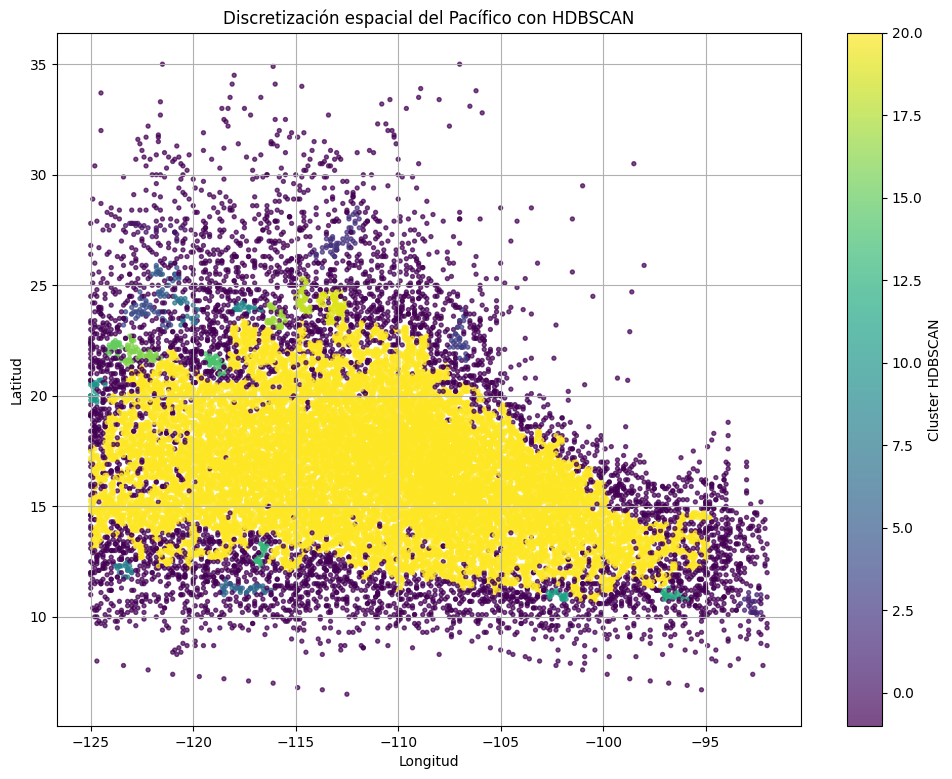

In [ ]:
# visualizar
plt.figure(figsize=(12, 9))

scatter = plt.scatter(
    puntos["lon"],
    puntos["lat"],
    c=puntos["cluster_hdbscan"],
    s=8,
    alpha=0.7
)

plt.colorbar(scatter, label="Cluster HDBSCAN")
plt.title("Discretización espacial del Pacífico con HDBSCAN")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)

plt.show()

## 2.4. Enriquecimiento ambiental con ERA5

Esta sección agrega variables atmosféricas/oceánicas de ERA5 como atributos de cada punto de trayectoria. La topología espacial sigue definida por HDBSCAN; ERA5 entra como capa ambiental para enriquecer puntos, nodos, aristas y el dataset final del modelo gráfico probabilístico.


In [ ]:
# ============================================================
# 2.4 ENRIQUECIMIENTO AMBIENTAL CON ERA5
# ============================================================
# Uso recomendado:
# 1) Descargar ERA5 en NetCDF (.nc) para el dominio del Pacífico mexicano.
# 2) Colocar los archivos en el mismo directorio del notebook o ajustar era5_paths.
# 3) Ejecutar esta celda después de crear puntos["node_id"].

import os
import glob
import sys
import subprocess
import numpy as np
import pandas as pd

try:
    import xarray as xr
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xarray", "netCDF4"], check=False)
    import xarray as xr

# Rutas ERA5. Puedes poner manualmente tus archivos .nc aquí.
era5_paths = sorted(glob.glob("era5*.nc")) + sorted(glob.glob("ERA5*.nc")) + sorted(glob.glob("*.nc"))
era5_paths = list(dict.fromkeys(era5_paths))

columnas_era5 = [
    "era5_sst_c",
    "era5_msl_hpa",
    "era5_t2m_c",
    "era5_d2m_c",
    "era5_rh700_pct",
    "era5_rh500_pct",
    "era5_q700_kgkg",
    "era5_vo850_s1",
    "era5_u850_ms",
    "era5_v850_ms",
    "era5_u200_ms",
    "era5_v200_ms",
    "era5_shear_200_850_ms"
]

for col in columnas_era5:
    if col not in puntos.columns:
        puntos[col] = np.nan


def estandarizar_coords_era5(ds):
    rename_map = {}
    if "valid_time" in ds.coords and "time" not in ds.coords:
        rename_map["valid_time"] = "time"
    if "latitude" in ds.coords and "lat" not in ds.coords:
        rename_map["latitude"] = "lat"
    if "longitude" in ds.coords and "lon" not in ds.coords:
        rename_map["longitude"] = "lon"
    if "pressure_level" in ds.coords and "level" not in ds.coords:
        rename_map["pressure_level"] = "level"
    if "isobaricInhPa" in ds.coords and "level" not in ds.coords:
        rename_map["isobaricInhPa"] = "level"
    if rename_map:
        ds = ds.rename(rename_map)
    return ds


def buscar_variable(ds, nombres):
    for nombre in nombres:
        if nombre in ds.data_vars:
            return nombre
    return None


def convertir_si_kelvin_a_celsius(vals):
    vals = np.asarray(vals, dtype=float)
    if np.nanmean(vals) > 100:
        return vals - 273.15
    return vals


def convertir_pa_a_hpa(vals):
    vals = np.asarray(vals, dtype=float)
    if np.nanmean(vals) > 2000:
        return vals / 100.0
    return vals


def extraer_da_en_puntos(da, puntos_df):
    puntos_dt = pd.to_datetime(puntos_df["datetime"], errors="coerce", utc=True).dt.tz_localize(None)
    times = xr.DataArray(puntos_dt.values.astype("datetime64[ns]"), dims="points")
    lats = xr.DataArray(puntos_df["lat"].astype(float).values, dims="points")

    lon_vals = puntos_df["lon"].astype(float).values.copy()
    if "lon" in da.coords:
        lon_coord = da["lon"].values
        if np.nanmin(lon_coord) >= 0 and np.nanmax(lon_coord) > 180:
            lon_vals = np.where(lon_vals < 0, lon_vals + 360, lon_vals)
    lons = xr.DataArray(lon_vals, dims="points")

    sel = da.sel(time=times, lat=lats, lon=lons, method="nearest")
    return np.asarray(sel.values, dtype=float)


def extraer_variable_superficie(ds, nombres, out_col, convert_func=None):
    nombre = buscar_variable(ds, nombres)
    if nombre is None:
        print(f"ERA5: no se encontró variable para {out_col}")
        return
    da = ds[nombre]
    try:
        vals = extraer_da_en_puntos(da, puntos)
        if convert_func is not None:
            vals = convert_func(vals)
        puntos[out_col] = vals
        print(f"ERA5: {out_col} <- {nombre}")
    except Exception as e:
        print(f"ERA5: error extrayendo {out_col} desde {nombre}: {e}")


def extraer_variable_nivel(ds, nombres, level_value, out_col, convert_func=None):
    nombre = buscar_variable(ds, nombres)
    if nombre is None:
        print(f"ERA5: no se encontró variable para {out_col}")
        return
    da = ds[nombre]
    try:
        if "level" in da.coords:
            da = da.sel(level=level_value, method="nearest")
        vals = extraer_da_en_puntos(da, puntos)
        if convert_func is not None:
            vals = convert_func(vals)
        puntos[out_col] = vals
        print(f"ERA5: {out_col} <- {nombre} nivel {level_value}")
    except Exception as e:
        print(f"ERA5: error extrayendo {out_col} desde {nombre}: {e}")

if len(era5_paths) == 0:
    print("No se encontraron archivos ERA5 .nc. Se dejan columnas ERA5 como NaN.")
    print("Coloca archivos ERA5 NetCDF en el directorio del notebook y vuelve a ejecutar esta celda.")
else:
    print("Archivos ERA5 encontrados:")
    for p in era5_paths:
        print("-", p)

    ds_era5 = xr.open_mfdataset(
        era5_paths,
        combine="by_coords",
        decode_times=True
    )
    ds_era5 = estandarizar_coords_era5(ds_era5)

    extraer_variable_superficie(ds_era5, ["sst", "sea_surface_temperature"], "era5_sst_c", convertir_si_kelvin_a_celsius)
    extraer_variable_superficie(ds_era5, ["msl", "mean_sea_level_pressure"], "era5_msl_hpa", convertir_pa_a_hpa)
    extraer_variable_superficie(ds_era5, ["t2m", "2m_temperature"], "era5_t2m_c", convertir_si_kelvin_a_celsius)
    extraer_variable_superficie(ds_era5, ["d2m", "2m_dewpoint_temperature"], "era5_d2m_c", convertir_si_kelvin_a_celsius)

    extraer_variable_nivel(ds_era5, ["r", "relative_humidity"], 700, "era5_rh700_pct")
    extraer_variable_nivel(ds_era5, ["r", "relative_humidity"], 500, "era5_rh500_pct")
    extraer_variable_nivel(ds_era5, ["q", "specific_humidity"], 700, "era5_q700_kgkg")
    extraer_variable_nivel(ds_era5, ["vo", "vorticity", "relative_vorticity"], 850, "era5_vo850_s1")
    extraer_variable_nivel(ds_era5, ["u", "u_component_of_wind"], 850, "era5_u850_ms")
    extraer_variable_nivel(ds_era5, ["v", "v_component_of_wind"], 850, "era5_v850_ms")
    extraer_variable_nivel(ds_era5, ["u", "u_component_of_wind"], 200, "era5_u200_ms")
    extraer_variable_nivel(ds_era5, ["v", "v_component_of_wind"], 200, "era5_v200_ms")

    if all(c in puntos.columns for c in ["era5_u200_ms", "era5_v200_ms", "era5_u850_ms", "era5_v850_ms"]):
        puntos["era5_shear_200_850_ms"] = np.sqrt(
            (puntos["era5_u200_ms"] - puntos["era5_u850_ms"]) ** 2 +
            (puntos["era5_v200_ms"] - puntos["era5_v850_ms"]) ** 2
        )

puntos.to_csv("puntos_enriquecidos_era5.csv", index=False, encoding="utf-8-sig")

display(puntos[["storm_id", "name", "datetime", "lat", "lon", "node_id"] + columnas_era5].head(20))
print("Columnas ERA5 agregadas:", columnas_era5)


No se encontraron archivos ERA5 .nc. Se dejan columnas ERA5 como NaN.
Coloca archivos ERA5 NetCDF en el directorio del notebook y vuelve a ejecutar esta celda.


,storm_id,name,datetime,lat,lon,node_id,era5_sst_c,era5_msl_hpa,era5_t2m_c,era5_d2m_c,era5_rh700_pct,era5_rh500_pct,era5_q700_kgkg,era5_vo850_s1,era5_u850_ms,era5_v850_ms,era5_u200_ms,era5_v200_ms,era5_shear_200_850_ms
0,CP032013,THREE,2013-08-09 06:00:00+00:00,11.0,-116.2,ruido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CP032013,THREE,2013-08-09 12:00:00+00:00,11.2,-116.2,HDB_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CP032013,THREE,2013-08-09 18:00:00+00:00,11.4,-116.8,HDB_6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CP032013,THREE,2013-08-10 00:00:00+00:00,11.6,-117.4,ruido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CP032013,THREE,2013-08-10 06:00:00+00:00,12.0,-118.1,ruido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CP032013,THREE,2013-08-10 12:00:00+00:00,12.4,-118.5,ruido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CP032013,THREE,2013-08-10 18:00:00+00:00,12.8,-118.8,HDB_20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CP032013,THREE,2013-08-11 00:00:00+00:00,13.0,-119.4,ruido,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CP032013,THREE,2013-08-11 06:00:00+00:00,13.2,-120.2,HDB_20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,CP032013,THREE,2013-08-11 12:00:00+00:00,13.2,-121.3,HDB_20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


Columnas ERA5 agregadas: ['era5_sst_c', 'era5_msl_hpa', 'era5_t2m_c', 'era5_d2m_c', 'era5_rh700_pct', 'era5_rh500_pct', 'era5_q700_kgkg', 'era5_vo850_s1', 'era5_u850_ms', 'era5_v850_ms', 'era5_u200_ms', 'era5_v200_ms', 'era5_shear_200_850_ms']


## 2.5. Enriquecimiento orográfico con CEM / grid

Esta sección agrega variables del grid orográfico como capa separada de ERA5: elevación, pendiente y rugosidad local. Se usa como atributo físico del punto de trayectoria y posteriormente se resume por nodo y arista.


In [ ]:
# ============================================================
# 2.5 ENRIQUECIMIENTO OROGRÁFICO CON CEM / GRID
# ============================================================
# Entrada esperada: CEM_pacifico913949 sq km(1).rar con CEM3.asc y CEM3.prj,
# o directamente CEM3.asc en el directorio del notebook.

import os
import glob
import sys
import subprocess
import numpy as np
import pandas as pd

for col in ["cem_elevacion_m", "cem_pendiente_grados", "cem_rugosidad_3x3_m"]:
    if col not in puntos.columns:
        puntos[col] = np.nan

try:
    import rasterio
    from rasterio.transform import rowcol
    from rasterio.warp import transform as rio_transform
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "rasterio", "rarfile"], check=False)
    import rasterio
    from rasterio.transform import rowcol
    from rasterio.warp import transform as rio_transform

try:
    from scipy.ndimage import generic_filter
except ImportError:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "scipy"], check=False)
    from scipy.ndimage import generic_filter

cem_dir = "cem_grid"
os.makedirs(cem_dir, exist_ok=True)

asc_candidates = sorted(glob.glob("CEM3.asc")) + sorted(glob.glob(os.path.join(cem_dir, "CEM3.asc")))
rar_candidates = sorted(glob.glob("CEM_pacifico*.rar"))

if len(asc_candidates) == 0 and len(rar_candidates) > 0:
    rar_path = rar_candidates[0]
    print("Intentando extraer:", rar_path)
    try:
        import rarfile
        with rarfile.RarFile(rar_path) as rf:
            rf.extractall(cem_dir)
    except Exception as e:
        print("Extracción con rarfile falló:", e)
        print("Intentando instalar unrar y extraer desde sistema...")
        subprocess.run(["apt-get", "update", "-qq"], check=False)
        subprocess.run(["apt-get", "install", "-y", "-qq", "unrar"], check=False)
        subprocess.run(["unrar", "x", "-o+", rar_path, cem_dir], check=False)

asc_candidates = sorted(glob.glob("CEM3.asc")) + sorted(glob.glob(os.path.join(cem_dir, "CEM3.asc")))

if len(asc_candidates) == 0:
    print("No se encontró CEM3.asc. Se dejan columnas CEM como NaN.")
else:
    cem_asc_path = asc_candidates[0]
    print("Usando grid CEM:", cem_asc_path)

    with rasterio.open(cem_asc_path) as src:
        arr = src.read(1, masked=True).astype(float).filled(np.nan)
        nodata = src.nodata
        if nodata is not None:
            arr = np.where(arr == nodata, np.nan, arr)

        if src.crs is not None and str(src.crs).upper() not in ["EPSG:4326", "OGC:CRS84"]:
            xs, ys = rio_transform("EPSG:4326", src.crs, puntos["lon"].astype(float).tolist(), puntos["lat"].astype(float).tolist())
        else:
            xs = puntos["lon"].astype(float).values
            ys = puntos["lat"].astype(float).values

        rows, cols = rowcol(src.transform, xs, ys)
        rows = np.asarray(rows)
        cols = np.asarray(cols)
        valid = (rows >= 0) & (rows < arr.shape[0]) & (cols >= 0) & (cols < arr.shape[1])

        elev = np.full(len(puntos), np.nan)
        elev[valid] = arr[rows[valid], cols[valid]]
        puntos["cem_elevacion_m"] = elev

        if src.crs is not None and src.crs.is_geographic:
            lat_media = np.nanmean(puntos["lat"].astype(float).values)
            dx = abs(src.transform.a) * 111320 * np.cos(np.deg2rad(lat_media))
            dy = abs(src.transform.e) * 111320
        else:
            dx = abs(src.transform.a)
            dy = abs(src.transform.e)

        dx = dx if dx > 0 else 1
        dy = dy if dy > 0 else 1

        arr_calc = arr.copy()
        arr_calc[np.isnan(arr_calc)] = np.nanmedian(arr_calc)

        grad_y, grad_x = np.gradient(arr_calc, dy, dx)
        pendiente = np.degrees(np.arctan(np.sqrt(grad_x ** 2 + grad_y ** 2)))
        rugosidad = generic_filter(arr_calc, np.std, size=3, mode="nearest")

        slope_vals = np.full(len(puntos), np.nan)
        rug_vals = np.full(len(puntos), np.nan)
        slope_vals[valid] = pendiente[rows[valid], cols[valid]]
        rug_vals[valid] = rugosidad[rows[valid], cols[valid]]

        puntos["cem_pendiente_grados"] = slope_vals
        puntos["cem_rugosidad_3x3_m"] = rug_vals

puntos.to_csv("puntos_enriquecidos_cem_grid.csv", index=False, encoding="utf-8-sig")

display(puntos[[
    "storm_id", "name", "datetime", "lat", "lon", "node_id",
    "cem_elevacion_m", "cem_pendiente_grados", "cem_rugosidad_3x3_m"
]].head(20))


Intentando extraer: CEM_pacifico913949 sq km.rar
Extracción con rarfile falló: No module named 'rarfile'
Intentando instalar unrar y extraer desde sistema...
Usando grid CEM: cem_grid/CEM3.asc


,storm_id,name,datetime,lat,lon,node_id,cem_elevacion_m,cem_pendiente_grados,cem_rugosidad_3x3_m
0,CP032013,THREE,2013-08-09 06:00:00+00:00,11.0,-116.2,ruido,NaN,NaN,NaN
1,CP032013,THREE,2013-08-09 12:00:00+00:00,11.2,-116.2,HDB_6,NaN,NaN,NaN
2,CP032013,THREE,2013-08-09 18:00:00+00:00,11.4,-116.8,HDB_6,NaN,NaN,NaN
3,CP032013,THREE,2013-08-10 00:00:00+00:00,11.6,-117.4,ruido,NaN,NaN,NaN
4,CP032013,THREE,2013-08-10 06:00:00+00:00,12.0,-118.1,ruido,NaN,NaN,NaN
5,CP032013,THREE,2013-08-10 12:00:00+00:00,12.4,-118.5,ruido,NaN,NaN,NaN
6,CP032013,THREE,2013-08-10 18:00:00+00:00,12.8,-118.8,HDB_20,NaN,NaN,NaN
7,CP032013,THREE,2013-08-11 00:00:00+00:00,13.0,-119.4,ruido,NaN,NaN,NaN
8,CP032013,THREE,2013-08-11 06:00:00+00:00,13.2,-120.2,HDB_20,NaN,NaN,NaN
9,CP032013,THREE,2013-08-11 12:00:00+00:00,13.2,-121.3,HDB_20,NaN,NaN,NaN


In [ ]:
# ============================================================
# CEM / OROGRAFÍA POR PROXIMIDAD COSTERA
# En lugar de usar solo el valor exacto del punto,
# calcula distancia al terreno válido y orografía cercana.
# ============================================================

import numpy as np
import pandas as pd

try:
    import rasterio
except:
    !pip install -q rasterio
    import rasterio

from scipy.spatial import cKDTree
from scipy.ndimage import generic_filter

# ------------------------------------------------------------
# 1. Abrir raster CEM
# ------------------------------------------------------------

cem_path = "cem_grid/CEM3.asc"

with rasterio.open(cem_path) as src:
    cem = src.read(1).astype(float)
    transform = src.transform
    nodata = src.nodata
    crs = src.crs

# ------------------------------------------------------------
# 2. Limpiar NoData
# ------------------------------------------------------------

if nodata is not None:
    cem[cem == nodata] = np.nan

# quitar valores muy extremos negativos si existen
cem[cem < -100] = np.nan

# máscara de terreno válido
mask_valid = np.isfinite(cem)

print("Celdas válidas CEM:", np.sum(mask_valid))
print("Total de celdas:", cem.size)
print("Porcentaje válido:", round(np.mean(mask_valid) * 100, 2), "%")

# ------------------------------------------------------------
# 3. Crear coordenadas lon/lat de celdas válidas
# ------------------------------------------------------------

rows, cols = np.where(mask_valid)

xs, ys = rasterio.transform.xy(
    transform,
    rows,
    cols,
    offset="center"
)

xs = np.array(xs)
ys = np.array(ys)

elev_valid = cem[rows, cols]

# ------------------------------------------------------------
# 4. Calcular pendiente y rugosidad del CEM
# ------------------------------------------------------------

# resolución aproximada del raster
xres = abs(transform.a)
yres = abs(transform.e)

# convertir grados a metros aproximados
lat_media = np.nanmean(ys)
m_por_grado_lon = 111320 * np.cos(np.deg2rad(lat_media))
m_por_grado_lat = 110540

dx_m = xres * m_por_grado_lon
dy_m = yres * m_por_grado_lat

cem_filled = np.where(np.isfinite(cem), cem, np.nanmedian(cem))

grad_y, grad_x = np.gradient(cem_filled, dy_m, dx_m)

pendiente = np.degrees(
    np.arctan(
        np.sqrt(grad_x**2 + grad_y**2)
    )
)

pendiente[~mask_valid] = np.nan

rugosidad = generic_filter(
    cem_filled,
    function=lambda x: np.nanmax(x) - np.nanmin(x),
    size=3,
    mode="nearest"
)

rugosidad[~mask_valid] = np.nan

pend_valid = pendiente[rows, cols]
rug_valid = rugosidad[rows, cols]

# ------------------------------------------------------------
# 5. KDTree para buscar terreno más cercano
# ------------------------------------------------------------

# Para distancias aproximadas en km
x_km = xs * 111.32 * np.cos(np.deg2rad(lat_media))
y_km = ys * 110.57

coords_valid_km = np.column_stack([x_km, y_km])

tree = cKDTree(coords_valid_km)

# puntos de huracanes
puntos_cem = puntos.copy()

px_km = puntos_cem["lon"].values * 111.32 * np.cos(np.deg2rad(lat_media))
py_km = puntos_cem["lat"].values * 110.57

coords_puntos_km = np.column_stack([px_km, py_km])

# ------------------------------------------------------------
# 6. Valor de terreno más cercano
# ------------------------------------------------------------

dist_km, idx_nearest = tree.query(coords_puntos_km, k=1)

puntos["cem_distancia_tierra_km"] = dist_km
puntos["cem_elevacion_cercana_m"] = elev_valid[idx_nearest]
puntos["cem_pendiente_cercana_grados"] = pend_valid[idx_nearest]
puntos["cem_rugosidad_cercana_m"] = rug_valid[idx_nearest]

# ------------------------------------------------------------
# 7. Estadísticas dentro de radios de influencia
# ------------------------------------------------------------

def stats_buffer_orografico(coord, radio_km):
    idxs = tree.query_ball_point(coord, r=radio_km)

    if len(idxs) == 0:
        return {
            "elev_mean": np.nan,
            "elev_max": np.nan,
            "pend_mean": np.nan,
            "pend_max": np.nan,
            "rug_mean": np.nan,
            "rug_max": np.nan,
            "n_celdas": 0
        }

    elev = elev_valid[idxs]
    pend = pend_valid[idxs]
    rug = rug_valid[idxs]

    return {
        "elev_mean": np.nanmean(elev),
        "elev_max": np.nanmax(elev),
        "pend_mean": np.nanmean(pend),
        "pend_max": np.nanmax(pend),
        "rug_mean": np.nanmean(rug),
        "rug_max": np.nanmax(rug),
        "n_celdas": len(idxs)
    }


radios_km = [25, 50, 100]

for radio in radios_km:

    stats_lista = [
        stats_buffer_orografico(coord, radio)
        for coord in coords_puntos_km
    ]

    stats_df = pd.DataFrame(stats_lista)

    puntos[f"cem_elevacion_media_{radio}km"] = stats_df["elev_mean"].values
    puntos[f"cem_elevacion_max_{radio}km"] = stats_df["elev_max"].values

    puntos[f"cem_pendiente_media_{radio}km"] = stats_df["pend_mean"].values
    puntos[f"cem_pendiente_max_{radio}km"] = stats_df["pend_max"].values

    puntos[f"cem_rugosidad_media_{radio}km"] = stats_df["rug_mean"].values
    puntos[f"cem_rugosidad_max_{radio}km"] = stats_df["rug_max"].values

    puntos[f"cem_celdas_validas_{radio}km"] = stats_df["n_celdas"].values

# ------------------------------------------------------------
# 8. Índice simple de interacción orográfica
# ------------------------------------------------------------

def minmax_col(s):
    s = pd.Series(s)
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

puntos["cem_distancia_tierra_norm"] = 1 - minmax_col(
    puntos["cem_distancia_tierra_km"]
)

puntos["cem_elevacion_max_50km_norm"] = minmax_col(
    puntos["cem_elevacion_max_50km"]
)

puntos["cem_pendiente_max_50km_norm"] = minmax_col(
    puntos["cem_pendiente_max_50km"]
)

puntos["cem_rugosidad_max_50km_norm"] = minmax_col(
    puntos["cem_rugosidad_max_50km"]
)

puntos["cem_interaccion_orografica_50km"] = (
    0.35 * puntos["cem_distancia_tierra_norm"] +
    0.25 * puntos["cem_elevacion_max_50km_norm"] +
    0.25 * puntos["cem_pendiente_max_50km_norm"] +
    0.15 * puntos["cem_rugosidad_max_50km_norm"]
)

# ------------------------------------------------------------
# 9. Clasificar interacción orográfica
# ------------------------------------------------------------

puntos["cem_clase_interaccion"] = pd.cut(
    puntos["cem_interaccion_orografica_50km"],
    bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
    labels=[
        "muy_baja",
        "baja",
        "media",
        "alta"
    ]
)

# ------------------------------------------------------------
# 10. Diagnóstico
# ------------------------------------------------------------

cols_revision = [
    "storm_id",
    "name",
    "datetime",
    "lat",
    "lon",
    "node_id",
    "cem_distancia_tierra_km",
    "cem_elevacion_cercana_m",
    "cem_elevacion_max_50km",
    "cem_pendiente_max_50km",
    "cem_rugosidad_max_50km",
    "cem_interaccion_orografica_50km",
    "cem_clase_interaccion"
]

display(puntos[cols_revision].head(30))

print("Cobertura nuevas variables CEM:")
for col in cols_revision[6:]:
    print(
        col,
        puntos[col].notna().sum(),
        "/",
        len(puntos),
        "(",
        round(puntos[col].notna().mean() * 100, 2),
        "% )"
    )

Celdas válidas CEM: 1801557
Total de celdas: 5793898
Porcentaje válido: 31.09 %


,storm_id,name,datetime,lat,lon,node_id,cem_distancia_tierra_km,cem_elevacion_cercana_m,cem_elevacion_max_50km,cem_pendiente_max_50km,cem_rugosidad_max_50km,cem_interaccion_orografica_50km,cem_clase_interaccion
0,CP032013,THREE,2013-08-09 06:00:00+00:00,11.0,-116.2,ruido,999.884587,-1.0,NaN,NaN,NaN,NaN,NaN
1,CP032013,THREE,2013-08-09 12:00:00+00:00,11.2,-116.2,HDB_6,981.094178,-1.0,NaN,NaN,NaN,NaN,NaN
2,CP032013,THREE,2013-08-09 18:00:00+00:00,11.4,-116.8,HDB_6,996.886059,-1.0,NaN,NaN,NaN,NaN,NaN
3,CP032013,THREE,2013-08-10 00:00:00+00:00,11.6,-117.4,ruido,1016.586713,-1.0,NaN,NaN,NaN,NaN,NaN
4,CP032013,THREE,2013-08-10 06:00:00+00:00,12.0,-118.1,ruido,1030.868802,-1.0,NaN,NaN,NaN,NaN,NaN
5,CP032013,THREE,2013-08-10 12:00:00+00:00,12.4,-118.5,ruido,1029.026334,-1.0,NaN,NaN,NaN,NaN,NaN
6,CP032013,THREE,2013-08-10 18:00:00+00:00,12.8,-118.8,HDB_20,1022.845348,-1.0,NaN,NaN,NaN,NaN,NaN
7,CP032013,THREE,2013-08-11 00:00:00+00:00,13.0,-119.4,ruido,1057.150840,-1.0,NaN,NaN,NaN,NaN,NaN
8,CP032013,THREE,2013-08-11 06:00:00+00:00,13.2,-120.2,HDB_20,1111.194391,-1.0,NaN,NaN,NaN,NaN,NaN
9,CP032013,THREE,2013-08-11 12:00:00+00:00,13.2,-121.3,HDB_20,1206.337312,-1.0,NaN,NaN,NaN,NaN,NaN


Cobertura nuevas variables CEM:
cem_distancia_tierra_km 21233 / 21233 ( 100.0 % )
cem_elevacion_cercana_m 21233 / 21233 ( 100.0 % )
cem_elevacion_max_50km 1166 / 21233 ( 5.49 % )
cem_pendiente_max_50km 1166 / 21233 ( 5.49 % )
cem_rugosidad_max_50km 1166 / 21233 ( 5.49 % )
cem_interaccion_orografica_50km 1166 / 21233 ( 5.49 % )
cem_clase_interaccion 1166 / 21233 ( 5.49 % )


In [ ]:
# ============================================================
# CEM / OROGRAFÍA MULTIESCALA COMPLETA
# Calcula 50, 100, 250 y 500 km si faltan
# ============================================================

import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 1. Corregir valores negativos de elevación cercana
# ------------------------------------------------------------

if "cem_elevacion_cercana_m" in puntos.columns:
    puntos.loc[
        puntos["cem_elevacion_cercana_m"] < 0,
        "cem_elevacion_cercana_m"
    ] = np.nan


# ------------------------------------------------------------
# 2. Función para calcular estadísticas por radio
# ------------------------------------------------------------

def stats_buffer_orografico(coord, radio_km):
    idxs = tree.query_ball_point(coord, r=radio_km)

    if len(idxs) == 0:
        return {
            "elev_mean": np.nan,
            "elev_max": np.nan,
            "pend_mean": np.nan,
            "pend_max": np.nan,
            "rug_mean": np.nan,
            "rug_max": np.nan,
            "n_celdas": 0
        }

    elev = np.array(elev_valid[idxs], dtype=float)
    pend = np.array(pend_valid[idxs], dtype=float)
    rug = np.array(rug_valid[idxs], dtype=float)

    elev[elev < 0] = np.nan
    pend[pend < 0] = np.nan
    rug[rug < 0] = np.nan

    return {
        "elev_mean": np.nanmean(elev) if np.isfinite(elev).sum() > 0 else np.nan,
        "elev_max": np.nanmax(elev) if np.isfinite(elev).sum() > 0 else np.nan,
        "pend_mean": np.nanmean(pend) if np.isfinite(pend).sum() > 0 else np.nan,
        "pend_max": np.nanmax(pend) if np.isfinite(pend).sum() > 0 else np.nan,
        "rug_mean": np.nanmean(rug) if np.isfinite(rug).sum() > 0 else np.nan,
        "rug_max": np.nanmax(rug) if np.isfinite(rug).sum() > 0 else np.nan,
        "n_celdas": len(idxs)
    }


# ------------------------------------------------------------
# 3. Calcular columnas faltantes para radios 50, 100, 250 y 500 km
# ------------------------------------------------------------

radios_km = [50, 100, 250, 500]

for radio in radios_km:

    col_check = f"cem_elevacion_max_{radio}km"

    if col_check in puntos.columns:
        print(f"Radio {radio} km ya existe. No se recalcula.")
        continue

    print(f"Calculando radio {radio} km...")

    stats_lista = []

    for i, coord in enumerate(coords_puntos_km):

        stats_lista.append(
            stats_buffer_orografico(coord, radio)
        )

        if (i + 1) % 3000 == 0:
            print(f"  {i + 1} / {len(coords_puntos_km)} puntos procesados")

    stats_df = pd.DataFrame(stats_lista)

    puntos[f"cem_elevacion_media_{radio}km"] = stats_df["elev_mean"].values
    puntos[f"cem_elevacion_max_{radio}km"] = stats_df["elev_max"].values

    puntos[f"cem_pendiente_media_{radio}km"] = stats_df["pend_mean"].values
    puntos[f"cem_pendiente_max_{radio}km"] = stats_df["pend_max"].values

    puntos[f"cem_rugosidad_media_{radio}km"] = stats_df["rug_mean"].values
    puntos[f"cem_rugosidad_max_{radio}km"] = stats_df["rug_max"].values

    puntos[f"cem_celdas_validas_{radio}km"] = stats_df["n_celdas"].values

    print(f"Radio {radio} km calculado.")


# ------------------------------------------------------------
# 4. Normalización segura
# ------------------------------------------------------------

def minmax_seguro(s):
    s = pd.Series(s).astype(float)

    if s.notna().sum() == 0:
        return pd.Series(np.nan, index=s.index)

    if s.max() == s.min():
        return pd.Series(0, index=s.index)

    return (s - s.min()) / (s.max() - s.min())


# ------------------------------------------------------------
# 5. Crear índices de interacción orográfica
# ------------------------------------------------------------

for radio in radios_km:

    elev_col = f"cem_elevacion_max_{radio}km"
    pend_col = f"cem_pendiente_max_{radio}km"
    rug_col = f"cem_rugosidad_max_{radio}km"

    if not all(c in puntos.columns for c in [elev_col, pend_col, rug_col]):
        print(f"No existen columnas para radio {radio} km. Saltando.")
        continue

    puntos[f"cem_elevacion_max_{radio}km_norm"] = minmax_seguro(
        puntos[elev_col]
    )

    puntos[f"cem_pendiente_max_{radio}km_norm"] = minmax_seguro(
        puntos[pend_col]
    )

    puntos[f"cem_rugosidad_max_{radio}km_norm"] = minmax_seguro(
        puntos[rug_col]
    )

    puntos[f"cem_proximidad_tierra_{radio}km"] = np.where(
        puntos["cem_distancia_tierra_km"] <= radio,
        1 - (puntos["cem_distancia_tierra_km"] / radio),
        0
    )

    puntos[f"cem_interaccion_orografica_{radio}km"] = (
        0.35 * puntos[f"cem_proximidad_tierra_{radio}km"] +
        0.25 * puntos[f"cem_elevacion_max_{radio}km_norm"] +
        0.25 * puntos[f"cem_pendiente_max_{radio}km_norm"] +
        0.15 * puntos[f"cem_rugosidad_max_{radio}km_norm"]
    )

    puntos[f"cem_clase_interaccion_{radio}km"] = pd.cut(
        puntos[f"cem_interaccion_orografica_{radio}km"],
        bins=[-0.01, 0.25, 0.50, 0.75, 1.01],
        labels=["muy_baja", "baja", "media", "alta"]
    )

print("Índices multiescala generados correctamente.")


# ------------------------------------------------------------
# 6. Diagnóstico final
# ------------------------------------------------------------

cols_revision = [
    "cem_distancia_tierra_km",
    "cem_elevacion_cercana_m"
]

for radio in radios_km:
    for base in [
        "cem_elevacion_max",
        "cem_pendiente_max",
        "cem_rugosidad_max",
        "cem_interaccion_orografica"
    ]:
        col = f"{base}_{radio}km"
        if col in puntos.columns:
            cols_revision.append(col)

print("\nCobertura CEM multiescala:")

for col in cols_revision:
    print(
        col,
        puntos[col].notna().sum(),
        "/",
        len(puntos),
        "(",
        round(puntos[col].notna().mean() * 100, 2),
        "% )"
    )

display(puntos[[
    "storm_id",
    "name",
    "datetime",
    "lat",
    "lon",
    "node_id"
] + cols_revision].head(30))

Radio 50 km ya existe. No se recalcula.
Radio 100 km ya existe. No se recalcula.
Calculando radio 250 km...
  3000 / 21233 puntos procesados
  6000 / 21233 puntos procesados
  9000 / 21233 puntos procesados
  12000 / 21233 puntos procesados
  15000 / 21233 puntos procesados
  18000 / 21233 puntos procesados
  21000 / 21233 puntos procesados
Radio 250 km calculado.
Calculando radio 500 km...
  3000 / 21233 puntos procesados
  6000 / 21233 puntos procesados
  9000 / 21233 puntos procesados
  12000 / 21233 puntos procesados
  15000 / 21233 puntos procesados
  18000 / 21233 puntos procesados
  21000 / 21233 puntos procesados
Radio 500 km calculado.
Índices multiescala generados correctamente.

Cobertura CEM multiescala:
cem_distancia_tierra_km 21233 / 21233 ( 100.0 % )
cem_elevacion_cercana_m 3404 / 21233 ( 16.03 % )
cem_elevacion_max_50km 1166 / 21233 ( 5.49 % )
cem_pendiente_max_50km 1166 / 21233 ( 5.49 % )
cem_rugosidad_max_50km 1166 / 21233 ( 5.49 % )
cem_interaccion_orografica_50km 11

,storm_id,name,datetime,lat,lon,node_id,cem_distancia_tierra_km,cem_elevacion_cercana_m,cem_elevacion_max_50km,cem_pendiente_max_50km,...,cem_rugosidad_max_100km,cem_interaccion_orografica_100km,cem_elevacion_max_250km,cem_pendiente_max_250km,cem_rugosidad_max_250km,cem_interaccion_orografica_250km,cem_elevacion_max_500km,cem_pendiente_max_500km,cem_rugosidad_max_500km,cem_interaccion_orografica_500km
0,CP032013,THREE,2013-08-09 06:00:00+00:00,11.0,-116.2,ruido,999.884587,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CP032013,THREE,2013-08-09 12:00:00+00:00,11.2,-116.2,HDB_6,981.094178,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CP032013,THREE,2013-08-09 18:00:00+00:00,11.4,-116.8,HDB_6,996.886059,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CP032013,THREE,2013-08-10 00:00:00+00:00,11.6,-117.4,ruido,1016.586713,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CP032013,THREE,2013-08-10 06:00:00+00:00,12.0,-118.1,ruido,1030.868802,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,CP032013,THREE,2013-08-10 12:00:00+00:00,12.4,-118.5,ruido,1029.026334,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,CP032013,THREE,2013-08-10 18:00:00+00:00,12.8,-118.8,HDB_20,1022.845348,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,CP032013,THREE,2013-08-11 00:00:00+00:00,13.0,-119.4,ruido,1057.150840,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,CP032013,THREE,2013-08-11 06:00:00+00:00,13.2,-120.2,HDB_20,1111.194391,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,CP032013,THREE,2013-08-11 12:00:00+00:00,13.2,-121.3,HDB_20,1206.337312,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
cem_cols_modelo = [
    "cem_distancia_tierra_km",
    "cem_interaccion_orografica_100km",
    "cem_interaccion_orografica_250km",
    "cem_interaccion_orografica_500km",
    "cem_elevacion_max_250km",
    "cem_pendiente_max_250km",
    "cem_rugosidad_max_250km",
    "cem_clase_interaccion_100km",
    "cem_clase_interaccion_250km"
]
# ============================================================
# SELECCIÓN FINAL DE VARIABLES CEM PARA EL MODELO
# ============================================================

cem_cols_modelo = [
    "cem_distancia_tierra_km",
    "cem_interaccion_orografica_100km",
    "cem_interaccion_orografica_250km",
    "cem_interaccion_orografica_500km",
    "cem_elevacion_max_250km",
    "cem_pendiente_max_250km",
    "cem_rugosidad_max_250km",
    "cem_clase_interaccion_100km",
    "cem_clase_interaccion_250km"
]

cem_cols_modelo = [
    c for c in cem_cols_modelo
    if c in puntos.columns
]

# Relleno numérico razonable:
# Si no hay interacción orográfica dentro del radio, se asume 0.
for col in cem_cols_modelo:
    if puntos[col].dtype.name != "category" and puntos[col].dtype == "object":
        continue

    if "interaccion_orografica" in col:
        puntos[col] = puntos[col].fillna(0)

    if "elevacion_max" in col:
        puntos[col] = puntos[col].fillna(0)

    if "pendiente_max" in col:
        puntos[col] = puntos[col].fillna(0)

    if "rugosidad_max" in col:
        puntos[col] = puntos[col].fillna(0)

# Variables categóricas
for col in ["cem_clase_interaccion_100km", "cem_clase_interaccion_250km"]:
    if col in puntos.columns:
        puntos[col] = puntos[col].astype("object").fillna("sin_interaccion")

display(puntos[[
    "storm_id",
    "name",
    "datetime",
    "lat",
    "lon",
    "node_id"
] + cem_cols_modelo].head(30))

print("Variables CEM finales para el modelo:")
for col in cem_cols_modelo:
    print("-", col)

,storm_id,name,datetime,lat,lon,node_id,cem_distancia_tierra_km,cem_interaccion_orografica_100km,cem_interaccion_orografica_250km,cem_interaccion_orografica_500km,cem_elevacion_max_250km,cem_pendiente_max_250km,cem_rugosidad_max_250km,cem_clase_interaccion_100km,cem_clase_interaccion_250km
0,CP032013,THREE,2013-08-09 06:00:00+00:00,11.0,-116.2,ruido,999.884587,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
1,CP032013,THREE,2013-08-09 12:00:00+00:00,11.2,-116.2,HDB_6,981.094178,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
2,CP032013,THREE,2013-08-09 18:00:00+00:00,11.4,-116.8,HDB_6,996.886059,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
3,CP032013,THREE,2013-08-10 00:00:00+00:00,11.6,-117.4,ruido,1016.586713,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
4,CP032013,THREE,2013-08-10 06:00:00+00:00,12.0,-118.1,ruido,1030.868802,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
5,CP032013,THREE,2013-08-10 12:00:00+00:00,12.4,-118.5,ruido,1029.026334,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
6,CP032013,THREE,2013-08-10 18:00:00+00:00,12.8,-118.8,HDB_20,1022.845348,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
7,CP032013,THREE,2013-08-11 00:00:00+00:00,13.0,-119.4,ruido,1057.150840,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
8,CP032013,THREE,2013-08-11 06:00:00+00:00,13.2,-120.2,HDB_20,1111.194391,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion
9,CP032013,THREE,2013-08-11 12:00:00+00:00,13.2,-121.3,HDB_20,1206.337312,0.000000,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion,sin_interaccion


Variables CEM finales para el modelo:
- cem_distancia_tierra_km
- cem_interaccion_orografica_100km
- cem_interaccion_orografica_250km
- cem_interaccion_orografica_500km
- cem_elevacion_max_250km
- cem_pendiente_max_250km
- cem_rugosidad_max_250km
- cem_clase_interaccion_100km
- cem_clase_interaccion_250km


## 2.6. Construcción de nodos topológicos enriquecidos

Cada nodo conserva sus atributos históricos y además agrega promedios, mínimos y máximos de variables ERA5 y CEM/grid cuando estén disponibles.


In [ ]:
puntos_nodos = puntos.copy()
puntos_nodos["datetime"] = pd.to_datetime(
    puntos_nodos["datetime"],
    errors="coerce"
)

puntos_nodos["year"] = puntos_nodos["datetime"].dt.year
puntos_nodos["month"] = puntos_nodos["datetime"].dt.month

puntos_validos = puntos_nodos[
    puntos_nodos["cluster_hdbscan"] != -1
].copy()

total_puntos_validos = len(puntos_validos)

print("Puntos totales:", len(puntos_nodos))
print("Puntos en nodos válidos:", len(puntos_validos))
print("Puntos considerados ruido:", len(puntos_nodos) - len(puntos_validos))
print("Nodos HDBSCAN:", puntos_validos["node_id"].nunique())

# meses frecuentes
def meses_frecuentes(x, top_n=3):
    conteo = x.dropna().value_counts().head(top_n)
    meses = []
    for mes, freq in conteo.items():
        meses.append(f"{int(mes)} ({freq})")
    return ", ".join(meses)

# dirección frecuente
def direccion_dominante(x):
    x = x.dropna()
    if len(x) == 0:
        return np.nan
    return x.value_counts().idxmax()

# moda categórica
def moda_categorica(x):
    x = x.dropna()
    if len(x) == 0:
        return np.nan
    return x.value_counts().idxmax()

# variables ambientales ERA5
columnas_era5 = [
    c for c in puntos_validos.columns
    if c.startswith("era5_") and pd.api.types.is_numeric_dtype(puntos_validos[c])
]

# variables CEM principales para nodos
columnas_cem_prioritarias = [
    "cem_distancia_tierra_km",
    "cem_elevacion_cercana_m",

    "cem_interaccion_orografica_100km",
    "cem_interaccion_orografica_250km",
    "cem_interaccion_orografica_500km",

    "cem_elevacion_max_100km",
    "cem_elevacion_max_250km",
    "cem_elevacion_max_500km",

    "cem_pendiente_max_100km",
    "cem_pendiente_max_250km",
    "cem_pendiente_max_500km",

    "cem_rugosidad_max_100km",
    "cem_rugosidad_max_250km",
    "cem_rugosidad_max_500km"
]

columnas_cem = [
    c for c in columnas_cem_prioritarias
    if c in puntos_validos.columns and pd.api.types.is_numeric_dtype(puntos_validos[c])
]

columnas_enriquecimiento = columnas_era5 + columnas_cem

print("Variables ERA5 agregadas a nodos:", columnas_era5)
print("Variables CEM agregadas a nodos:", columnas_cem)

agg_nodos = {
    "cluster_hdbscan": ("cluster_hdbscan", "first"),
    "lat_centro": ("lat", "mean"),
    "lon_centro": ("lon", "mean"),
    "lat_min": ("lat", "min"),
    "lat_max": ("lat", "max"),
    "lon_min": ("lon", "min"),
    "lon_max": ("lon", "max"),
    "numero_puntos_historicos": ("datetime", "count"),
    "numero_huracanes_unicos": ("storm_id", "nunique"),
    "anios_unicos": ("year", "nunique"),
    "fecha_inicio": ("datetime", "min"),
    "fecha_fin": ("datetime", "max"),
    "intensidad_media": ("max_wind_kt", "mean"),
    "intensidad_maxima": ("max_wind_kt", "max"),
    "intensidad_minima": ("max_wind_kt", "min"),
    "presion_media": ("min_pressure_mb", "mean"),
    "presion_minima": ("min_pressure_mb", "min"),
    "presion_maxima": ("min_pressure_mb", "max"),
    "velocidad_media_kmh": ("velocidad_kmh_t", "mean"),
    "velocidad_maxima_kmh": ("velocidad_kmh_t", "max"),
    "distancia_media_km": ("distancia_recorrida_km_t", "mean"),
    "probabilidad_cluster_media": ("cluster_probabilidad", "mean")
}

# agregados numéricos ERA5 + CEM
for col in columnas_enriquecimiento:
    agg_nodos[f"{col}_media"] = (col, "mean")
    agg_nodos[f"{col}_min"] = (col, "min")
    agg_nodos[f"{col}_max"] = (col, "max")
    agg_nodos[f"{col}_cobertura"] = (col, lambda x: x.notna().mean())

nodos_topologicos = (
    puntos_validos
    .groupby("node_id")
    .agg(**agg_nodos)
    .reset_index()
)

# meses frecuentes por nodo
meses_por_nodo = (
    puntos_validos
    .groupby("node_id")["month"]
    .apply(lambda x: meses_frecuentes(x, top_n=3))
    .reset_index(name="meses_frecuentes")
)

nodos_topologicos = nodos_topologicos.merge(
    meses_por_nodo,
    on="node_id",
    how="left"
)

# dirección dominante por nodo
if "direccion_cardinal_t" in puntos_validos.columns:
    direccion_por_nodo = (
        puntos_validos
        .groupby("node_id")["direccion_cardinal_t"]
        .apply(direccion_dominante)
        .reset_index(name="direccion_dominante")
    )

    nodos_topologicos = nodos_topologicos.merge(
        direccion_por_nodo,
        on="node_id",
        how="left"
    )
else:
    nodos_topologicos["direccion_dominante"] = np.nan

# clase dominante de interacción orográfica por nodo
columnas_cem_categoricas = [
    "cem_clase_interaccion_100km",
    "cem_clase_interaccion_250km",
    "cem_clase_interaccion_500km"
]

columnas_cem_categoricas = [
    c for c in columnas_cem_categoricas
    if c in puntos_validos.columns
]

for col in columnas_cem_categoricas:

    cem_cat_nodo = (
        puntos_validos
        .groupby("node_id")[col]
        .apply(moda_categorica)
        .reset_index(name=f"{col}_dominante")
    )

    nodos_topologicos = nodos_topologicos.merge(
        cem_cat_nodo,
        on="node_id",
        how="left"
    )

# probabilidad de aparición del nodo
nodos_topologicos["probabilidad_aparicion"] = (
    nodos_topologicos["numero_puntos_historicos"] /
    total_puntos_validos
)

# duración histórica del nodo
nodos_topologicos["duracion_historica_dias"] = (
    nodos_topologicos["fecha_fin"] -
    nodos_topologicos["fecha_inicio"]
).dt.total_seconds() / 86400

nodos_topologicos["duracion_historica_anios"] = (
    nodos_topologicos["duracion_historica_dias"] / 365.25
)

# ordenar por importancia histórica
nodos_topologicos = nodos_topologicos.sort_values(
    by=[
        "numero_huracanes_unicos",
        "numero_puntos_historicos",
        "probabilidad_aparicion"
    ],
    ascending=False
).reset_index(drop=True)

display(nodos_topologicos)
print("Total de nodos topológicos construidos:", len(nodos_topologicos))
print("Variables enriquecidas agregadas a nodos:", columnas_enriquecimiento)


Puntos totales: 21233
Puntos en nodos válidos: 16100
Puntos considerados ruido: 5133
Nodos HDBSCAN: 21
Variables ERA5 agregadas a nodos: ['era5_sst_c', 'era5_msl_hpa', 'era5_t2m_c', 'era5_d2m_c', 'era5_rh700_pct', 'era5_rh500_pct', 'era5_q700_kgkg', 'era5_vo850_s1', 'era5_u850_ms', 'era5_v850_ms', 'era5_u200_ms', 'era5_v200_ms', 'era5_shear_200_850_ms']
Variables CEM agregadas a nodos: ['cem_distancia_tierra_km', 'cem_elevacion_cercana_m', 'cem_interaccion_orografica_100km', 'cem_interaccion_orografica_250km', 'cem_interaccion_orografica_500km', 'cem_elevacion_max_100km', 'cem_elevacion_max_250km', 'cem_elevacion_max_500km', 'cem_pendiente_max_100km', 'cem_pendiente_max_250km', 'cem_pendiente_max_500km', 'cem_rugosidad_max_100km', 'cem_rugosidad_max_250km', 'cem_rugosidad_max_500km']


,node_id,cluster_hdbscan,lat_centro,lon_centro,lat_min,lat_max,lon_min,lon_max,numero_puntos_historicos,numero_huracanes_unicos,...,cem_rugosidad_max_500km_max,cem_rugosidad_max_500km_cobertura,meses_frecuentes,direccion_dominante,cem_clase_interaccion_100km_dominante,cem_clase_interaccion_250km_dominante,cem_clase_interaccion_500km_dominante,probabilidad_aparicion,duracion_historica_dias,duracion_historica_anios
0,HDB_20,20,16.571373,-111.313795,10.7,23.5,-125.0,-94.8,15440,1043,...,3038.0,0.581347,"9 (3584), 8 (3278), 7 (3230)",W,sin_interaccion,sin_interaccion,baja,0.959006,27898.50,76.381930
1,HDB_19,19,24.034848,-113.153030,23.3,24.7,-113.9,-112.6,66,39,...,1236.0,1.000000,"9 (46), 8 (13), 7 (4)",NW,sin_interaccion,baja,baja,0.004099,26664.00,73.002053
2,HDB_16,16,21.914545,-122.690909,21.4,22.7,-123.3,-121.6,55,36,...,NaN,0.000000,"8 (21), 9 (15), 7 (14)",W,sin_interaccion,sin_interaccion,NaN,0.003416,24083.25,65.936345
3,HDB_2,2,27.020370,-112.922222,25.8,28.5,-114.3,-111.9,54,30,...,1533.0,1.000000,"9 (32), 8 (13), 10 (7)",N,media,media,media,0.003354,24890.50,68.146475
4,HDB_18,18,24.361538,-114.630769,23.7,25.3,-115.0,-114.3,39,28,...,1236.0,1.000000,"9 (23), 8 (6), 10 (6)",NW,sin_interaccion,muy_baja,baja,0.002422,25965.50,71.089665
5,HDB_10,10,20.227586,-124.800000,19.7,20.7,-125.0,-124.3,29,28,...,NaN,0.000000,"7 (11), 8 (10), 9 (5)",W,sin_interaccion,sin_interaccion,NaN,0.001801,25626.50,70.161533
6,HDB_14,14,21.490323,-118.938710,20.9,21.9,-119.4,-118.4,31,26,...,NaN,0.000000,"8 (11), 7 (8), 9 (8)",NW,sin_interaccion,sin_interaccion,NaN,0.001925,24800.00,67.898700
7,HDB_3,3,22.585714,-106.997143,21.6,23.9,-107.5,-106.6,35,24,...,1533.0,1.000000,"10 (16), 9 (12), 7 (3)",N,baja,media,media,0.002174,23367.50,63.976728
8,HDB_6,6,11.277500,-117.570000,11.0,11.7,-118.6,-116.2,40,22,...,NaN,0.000000,"8 (15), 7 (12), 6 (8)",W,sin_interaccion,sin_interaccion,NaN,0.002484,17925.25,49.076660
9,HDB_4,4,23.795238,-122.288095,23.1,24.7,-123.4,-121.1,42,21,...,NaN,0.000000,"8 (16), 7 (14), 10 (6)",W,sin_interaccion,sin_interaccion,NaN,0.002609,24069.50,65.898700


Total de nodos topológicos construidos: 21
Variables enriquecidas agregadas a nodos: ['era5_sst_c', 'era5_msl_hpa', 'era5_t2m_c', 'era5_d2m_c', 'era5_rh700_pct', 'era5_rh500_pct', 'era5_q700_kgkg', 'era5_vo850_s1', 'era5_u850_ms', 'era5_v850_ms', 'era5_u200_ms', 'era5_v200_ms', 'era5_shear_200_850_ms', 'cem_distancia_tierra_km', 'cem_elevacion_cercana_m', 'cem_interaccion_orografica_100km', 'cem_interaccion_orografica_250km', 'cem_interaccion_orografica_500km', 'cem_elevacion_max_100km', 'cem_elevacion_max_250km', 'cem_elevacion_max_500km', 'cem_pendiente_max_100km', 'cem_pendiente_max_250km', 'cem_pendiente_max_500km', 'cem_rugosidad_max_100km', 'cem_rugosidad_max_250km', 'cem_rugosidad_max_500km']


In [ ]:
# tabla resumen de nodos topológicos enriquecidos
columnas_resumen_nodos = [
    "node_id",
    "cluster_hdbscan",
    "lat_centro",
    "lon_centro",

    "numero_puntos_historicos",
    "numero_huracanes_unicos",
    "anios_unicos",

    "intensidad_media",
    "intensidad_maxima",
    "presion_media",
    "presion_minima",

    "meses_frecuentes",
    "velocidad_media_kmh",
    "direccion_dominante",
    "probabilidad_aparicion",

    # ERA5 principales
    "era5_sst_c_media",
    "era5_msl_hpa_media",
    "era5_t2m_c_media",
    "era5_rh700_pct_media",
    "era5_vo850_s1_media",
    "era5_shear_200_850_ms_media",

    # CEM / orografía principales
    "cem_distancia_tierra_km_media",
    "cem_interaccion_orografica_100km_media",
    "cem_interaccion_orografica_250km_media",
    "cem_interaccion_orografica_500km_media",

    "cem_elevacion_max_250km_max",
    "cem_pendiente_max_250km_max",
    "cem_rugosidad_max_250km_max",

    "cem_interaccion_orografica_250km_cobertura",
    "cem_clase_interaccion_250km_dominante"
]

columnas_resumen_nodos = [
    c for c in columnas_resumen_nodos
    if c in nodos_topologicos.columns
]

display(nodos_topologicos[columnas_resumen_nodos])

,node_id,cluster_hdbscan,lat_centro,lon_centro,numero_puntos_historicos,numero_huracanes_unicos,anios_unicos,intensidad_media,intensidad_maxima,presion_media,...,era5_shear_200_850_ms_media,cem_distancia_tierra_km_media,cem_interaccion_orografica_100km_media,cem_interaccion_orografica_250km_media,cem_interaccion_orografica_500km_media,cem_elevacion_max_250km_max,cem_pendiente_max_250km_max,cem_rugosidad_max_250km_max,cem_interaccion_orografica_250km_cobertura,cem_clase_interaccion_250km_dominante
0,HDB_20,20,16.571373,-111.313795,15440,1043,77,51.397085,185,993.496959,...,NaN,499.659551,0.014231,0.087142,0.213102,4218.0,36.231515,1669.0,1.0,sin_interaccion
1,HDB_19,19,24.034848,-113.153030,66,39,29,38.409091,110,1000.175000,...,NaN,120.344663,0.072829,0.373342,0.446270,1738.0,33.872035,1056.0,1.0,baja
2,HDB_16,16,21.914545,-122.690909,55,36,31,42.090909,95,1000.172414,...,NaN,889.689744,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
3,HDB_2,2,27.020370,-112.922222,54,30,27,39.444444,75,999.777778,...,NaN,16.040845,0.497335,0.570940,0.559820,2089.0,33.872035,1236.0,1.0,media
4,HDB_18,18,24.361538,-114.630769,39,28,25,39.743590,90,999.645161,...,NaN,236.789884,0.000000,0.116871,0.362341,876.0,33.872035,1005.0,1.0,muy_baja
5,HDB_10,10,20.227586,-124.800000,29,28,25,38.965517,75,1004.882353,...,NaN,1161.365772,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
6,HDB_14,14,21.490323,-118.938710,31,26,21,52.903226,95,991.000000,...,NaN,762.267280,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
7,HDB_3,3,22.585714,-106.997143,35,24,22,58.714286,120,991.444444,...,NaN,56.755382,0.310643,0.600494,0.616298,3209.0,37.101306,1529.0,1.0,media
8,HDB_6,6,11.277500,-117.570000,40,22,19,42.750000,100,996.050000,...,NaN,1056.871605,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
9,HDB_4,4,23.795238,-122.288095,42,21,21,31.309524,75,1006.466667,...,NaN,694.222910,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion


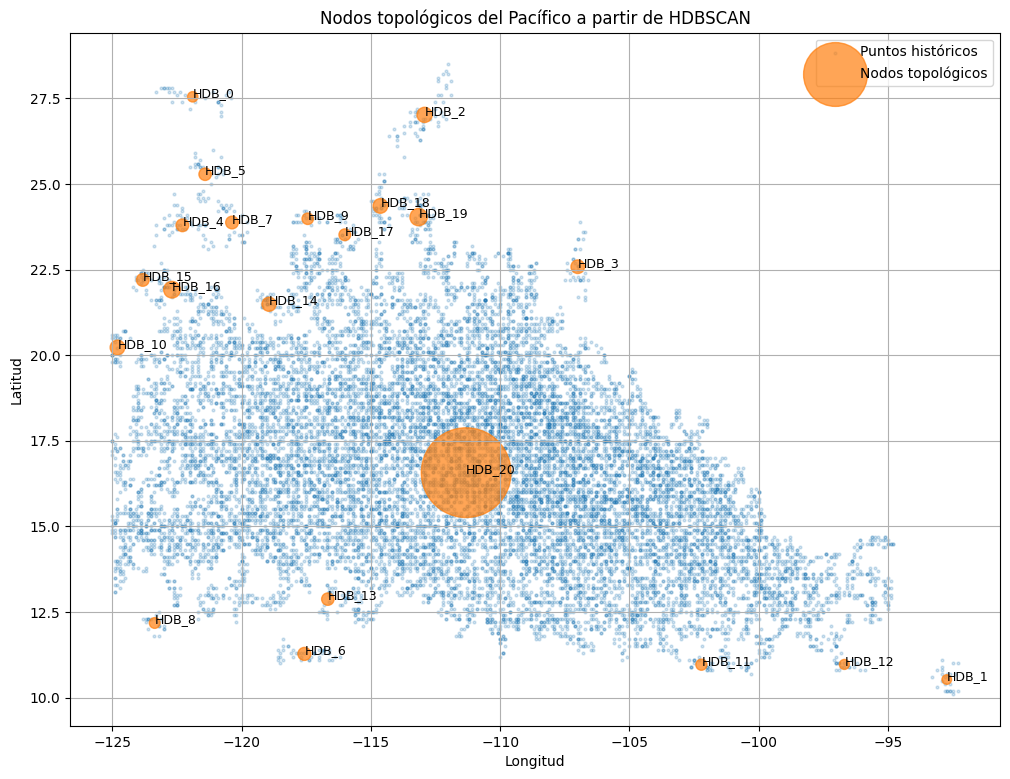

In [ ]:
#visualizar
plt.figure(figsize=(12, 9))

# Puntos históricos
plt.scatter(
    puntos_validos["lon"],
    puntos_validos["lat"],
    s=4,
    alpha=0.2,
    label="Puntos históricos"
)

# Nodos
plt.scatter(
    nodos_topologicos["lon_centro"],
    nodos_topologicos["lat_centro"],
    s=nodos_topologicos["numero_huracanes_unicos"] * 4,
    alpha=0.7,
    label="Nodos topológicos"
)

# Etiquetas
for _, row in nodos_topologicos.iterrows():
    plt.text(
        row["lon_centro"],
        row["lat_centro"],
        row["node_id"],
        fontsize=9
    )

plt.title("Nodos topológicos del Pacífico a partir de HDBSCAN")
plt.xlabel("Longitud")
plt.ylabel("Latitud")
plt.grid(True)
plt.legend()
plt.show()

## 2.7. Construcción de aristas topológicas enriquecidas

Cada arista conserva frecuencia, probabilidad y dinámica de transición, además de agregados ambientales ERA5 y orográficos CEM/grid cuando estén disponibles.


In [ ]:
# ============================================================
# TRANSICIONES PUNTO A PUNTO PARA CONSTRUIR ARISTAS
# ============================================================

puntos_aristas = puntos.copy()

puntos_aristas["datetime"] = pd.to_datetime(
    puntos_aristas["datetime"],
    errors="coerce"
)

puntos_aristas["year"] = puntos_aristas["datetime"].dt.year
puntos_aristas["month"] = puntos_aristas["datetime"].dt.month

puntos_aristas = puntos_aristas.sort_values(
    ["storm_id", "datetime"]
).reset_index(drop=True)

# nodo anterior dentro de cada trayectoria
puntos_aristas["node_origen"] = (
    puntos_aristas.groupby("storm_id")["node_id"].shift(1)
)

puntos_aristas["node_destino"] = puntos_aristas["node_id"]

# fecha anterior
puntos_aristas["datetime_origen"] = (
    puntos_aristas.groupby("storm_id")["datetime"].shift(1)
)

# tabla de transiciones
transiciones = puntos_aristas.dropna(
    subset=["node_origen", "node_destino"]
).copy()

# quitar ruido
transiciones = transiciones[
    (transiciones["node_origen"] != "ruido") &
    (transiciones["node_destino"] != "ruido")
].copy()

# quitar autotransiciones inmediatas
transiciones = transiciones[
    transiciones["node_origen"] != transiciones["node_destino"]
].copy()

# identificador de arista
transiciones["edge_id"] = (
    transiciones["node_origen"].astype(str) +
    " -> " +
    transiciones["node_destino"].astype(str)
)

# columnas base para visualizar transiciones
columnas_display_transiciones = [
    "storm_id",
    "name",
    "datetime_origen",
    "datetime",
    "node_origen",
    "node_destino",
    "edge_id",
    "velocidad_kmh_t",
    "direccion_grados_t",
    "cambio_intensidad_t",
    "cambio_presion_t",
    "month"
]

# variables ERA5 principales en la transición
columnas_era5_transiciones = [
    "era5_sst_c",
    "era5_msl_hpa",
    "era5_t2m_c",
    "era5_rh700_pct",
    "era5_vo850_s1",
    "era5_shear_200_850_ms"
]

# variables CEM principales en la transición
columnas_cem_transiciones = [
    "cem_distancia_tierra_km",
    "cem_interaccion_orografica_100km",
    "cem_interaccion_orografica_250km",
    "cem_interaccion_orografica_500km",
    "cem_elevacion_max_250km",
    "cem_pendiente_max_250km",
    "cem_rugosidad_max_250km",
    "cem_clase_interaccion_250km"
]

columnas_display_transiciones = (
    columnas_display_transiciones +
    columnas_era5_transiciones +
    columnas_cem_transiciones
)

columnas_display_transiciones = [
    c for c in columnas_display_transiciones
    if c in transiciones.columns
]

display(transiciones[columnas_display_transiciones].head(20))

print("Transiciones punto a punto:", len(transiciones))
print("Aristas únicas:", transiciones["edge_id"].nunique())


,storm_id,name,datetime_origen,datetime,node_origen,node_destino,edge_id,velocidad_kmh_t,direccion_grados_t,cambio_intensidad_t,...,era5_vo850_s1,era5_shear_200_850_ms,cem_distancia_tierra_km,cem_interaccion_orografica_100km,cem_interaccion_orografica_250km,cem_interaccion_orografica_500km,cem_elevacion_max_250km,cem_pendiente_max_250km,cem_rugosidad_max_250km,cem_clase_interaccion_250km
72,EP011953,UNNAMED,1953-08-26 12:00:00+00:00,1953-08-26 18:00:00+00:00,HDB_20,HDB_19,HDB_20 -> HDB_19,12.234299,335.410108,0.0,...,NaN,NaN,123.993669,0.0,0.362447,0.443716,865.0,33.872035,1005.0,baja
411,EP011973,AVA,1973-06-08 06:00:00+00:00,1973-06-08 12:00:00+00:00,HDB_13,HDB_20,HDB_13 -> HDB_20,29.393140,281.085887,0.0,...,NaN,NaN,933.574111,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
1414,EP021949,UNNAMED,1949-06-22 12:00:00+00:00,1949-06-22 18:00:00+00:00,HDB_20,HDB_9,HDB_20 -> HDB_9,14.825990,0.000000,0.0,...,NaN,NaN,511.873211,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
1605,EP021966,BLANCA,1966-08-04 12:00:00+00:00,1966-08-04 18:00:00+00:00,HDB_20,HDB_10,HDB_20 -> HDB_10,24.521352,292.419178,0.0,...,NaN,NaN,1205.956065,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
1836,EP021981,BEATRIZ,1981-07-03 06:00:00+00:00,1981-07-03 12:00:00+00:00,HDB_20,HDB_14,HDB_20 -> HDB_14,20.295242,317.070622,-5.0,...,NaN,NaN,731.229766,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
1860,EP021983,BARBARA,1983-06-11 00:00:00+00:00,1983-06-11 06:00:00+00:00,HDB_11,HDB_20,HDB_11 -> HDB_20,11.069574,279.695155,0.0,...,NaN,NaN,706.872411,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
2020,EP021987,BEATRIZ,1987-07-03 12:00:00+00:00,1987-07-03 18:00:00+00:00,HDB_20,HDB_13,HDB_20 -> HDB_13,13.172463,286.421240,0.0,...,NaN,NaN,837.773019,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
2100,EP021991,BLANCA,1991-06-18 12:00:00+00:00,1991-06-18 18:00:00+00:00,HDB_20,HDB_13,HDB_20 -> HDB_13,18.027945,270.115877,0.0,...,NaN,NaN,799.566086,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
2101,EP021991,BLANCA,1991-06-18 18:00:00+00:00,1991-06-19 00:00:00+00:00,HDB_13,HDB_20,HDB_13 -> HDB_20,18.126669,264.247501,0.0,...,NaN,NaN,879.298424,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion
3033,EP031975,CARLOTTA,1975-07-02 12:00:00+00:00,1975-07-02 18:00:00+00:00,HDB_11,HDB_20,HDB_11 -> HDB_20,17.957359,294.469173,10.0,...,NaN,NaN,676.838340,0.0,0.000000,0.000000,0.0,0.000000,0.0,sin_interaccion


Transiciones punto a punto: 149
Aristas únicas: 24


In [ ]:
# funciones
def direccion_media_circular(grados):
    grados = grados.dropna()

    if len(grados) == 0:
        return np.nan

    rad = np.deg2rad(grados)

    x = np.mean(np.cos(rad))
    y = np.mean(np.sin(rad))

    angulo = np.rad2deg(np.arctan2(y, x))

    return (angulo + 360) % 360


def meses_frecuentes_arista(x, top_n=3):
    conteo = x.value_counts().head(top_n)

    meses = []
    for mes, freq in conteo.items():
        meses.append(f"{int(mes)} ({freq})")

    return ", ".join(meses)

In [ ]:
# ============================================================
# RESUMEN DE ARISTAS TOPOLÓGICAS ENRIQUECIDAS
# ============================================================

# variables ERA5 numéricas
columnas_era5_aristas = [
    c for c in transiciones.columns
    if c.startswith("era5_") and pd.api.types.is_numeric_dtype(transiciones[c])
]

# variables CEM principales para aristas
columnas_cem_prioritarias_aristas = [
    "cem_distancia_tierra_km",
    "cem_elevacion_cercana_m",

    "cem_interaccion_orografica_100km",
    "cem_interaccion_orografica_250km",
    "cem_interaccion_orografica_500km",

    "cem_elevacion_max_100km",
    "cem_elevacion_max_250km",
    "cem_elevacion_max_500km",

    "cem_pendiente_max_100km",
    "cem_pendiente_max_250km",
    "cem_pendiente_max_500km",

    "cem_rugosidad_max_100km",
    "cem_rugosidad_max_250km",
    "cem_rugosidad_max_500km"
]

columnas_cem_aristas = [
    c for c in columnas_cem_prioritarias_aristas
    if c in transiciones.columns and pd.api.types.is_numeric_dtype(transiciones[c])
]

columnas_enriquecimiento_aristas = columnas_era5_aristas + columnas_cem_aristas

print("Variables ERA5 agregadas a aristas:", columnas_era5_aristas)
print("Variables CEM agregadas a aristas:", columnas_cem_aristas)

agg_aristas = {
    "frecuencia_transicion": ("edge_id", "count"),
    "huracanes_unicos": ("storm_id", "nunique"),
    "anios_unicos": ("year", "nunique"),
    "velocidad_media": ("velocidad_kmh_t", "mean"),
    "velocidad_maxima": ("velocidad_kmh_t", "max"),
    "cambio_promedio_intensidad": ("cambio_intensidad_t", "mean"),
    "cambio_maximo_intensidad": ("cambio_intensidad_t", "max"),
    "cambio_minimo_intensidad": ("cambio_intensidad_t", "min"),
    "cambio_promedio_presion": ("cambio_presion_t", "mean"),
    "cambio_minimo_presion": ("cambio_presion_t", "min"),
    "cambio_maximo_presion": ("cambio_presion_t", "max"),
    "distancia_media_km": ("distancia_recorrida_km_t", "mean"),
    "fecha_inicio": ("datetime", "min"),
    "fecha_fin": ("datetime", "max")
}

# agregados numéricos ERA5 + CEM
for col in columnas_enriquecimiento_aristas:
    agg_aristas[f"{col}_media_arista"] = (col, "mean")
    agg_aristas[f"{col}_min_arista"] = (col, "min")
    agg_aristas[f"{col}_max_arista"] = (col, "max")
    agg_aristas[f"{col}_cobertura_arista"] = (col, lambda x: x.notna().mean())

aristas_topologicas = (
    transiciones
    .groupby(["node_origen", "node_destino", "edge_id"])
    .agg(**agg_aristas)
    .reset_index()
)

# dirección media circular
direccion_media = (
    transiciones
    .groupby(["node_origen", "node_destino", "edge_id"])["direccion_grados_t"]
    .apply(direccion_media_circular)
    .reset_index(name="direccion_media_grados")
)

aristas_topologicas = aristas_topologicas.merge(
    direccion_media,
    on=["node_origen", "node_destino", "edge_id"],
    how="left"
)

# meses de transición
meses_arista = (
    transiciones
    .groupby(["node_origen", "node_destino", "edge_id"])["month"]
    .apply(lambda x: meses_frecuentes_arista(x, top_n=4))
    .reset_index(name="meses_donde_ocurre")
)

aristas_topologicas = aristas_topologicas.merge(
    meses_arista,
    on=["node_origen", "node_destino", "edge_id"],
    how="left"
)

# clase dominante de interacción orográfica por arista
def moda_categorica_arista(x):
    x = x.dropna()
    if len(x) == 0:
        return np.nan
    return x.value_counts().idxmax()

columnas_cem_categoricas_aristas = [
    "cem_clase_interaccion_100km",
    "cem_clase_interaccion_250km",
    "cem_clase_interaccion_500km"
]

columnas_cem_categoricas_aristas = [
    c for c in columnas_cem_categoricas_aristas
    if c in transiciones.columns
]

for col in columnas_cem_categoricas_aristas:

    cem_cat_arista = (
        transiciones
        .groupby(["node_origen", "node_destino", "edge_id"])[col]
        .apply(moda_categorica_arista)
        .reset_index(name=f"{col}_dominante_arista")
    )

    aristas_topologicas = aristas_topologicas.merge(
        cem_cat_arista,
        on=["node_origen", "node_destino", "edge_id"],
        how="left"
    )

columnas_resumen_aristas = [
    "node_origen",
    "node_destino",
    "edge_id",
    "frecuencia_transicion",
    "huracanes_unicos",
    "anios_unicos",
    "velocidad_media",
    "direccion_media_grados",
    "cambio_promedio_intensidad",
    "cambio_promedio_presion",
    "distancia_media_km",
    "meses_donde_ocurre",

    # ERA5 principales
    "era5_sst_c_media_arista",
    "era5_msl_hpa_media_arista",
    "era5_t2m_c_media_arista",
    "era5_rh700_pct_media_arista",
    "era5_vo850_s1_media_arista",
    "era5_shear_200_850_ms_media_arista",

    # CEM principales
    "cem_distancia_tierra_km_media_arista",
    "cem_interaccion_orografica_100km_media_arista",
    "cem_interaccion_orografica_250km_media_arista",
    "cem_interaccion_orografica_500km_media_arista",

    "cem_elevacion_max_250km_max_arista",
    "cem_pendiente_max_250km_max_arista",
    "cem_rugosidad_max_250km_max_arista",

    "cem_interaccion_orografica_250km_cobertura_arista",
    "cem_clase_interaccion_250km_dominante_arista"
]

columnas_resumen_aristas = [
    c for c in columnas_resumen_aristas
    if c in aristas_topologicas.columns
]

display(aristas_topologicas[columnas_resumen_aristas].head(20))
print("Variables enriquecidas agregadas a aristas:", columnas_enriquecimiento_aristas)


Variables ERA5 agregadas a aristas: ['era5_sst_c', 'era5_msl_hpa', 'era5_t2m_c', 'era5_d2m_c', 'era5_rh700_pct', 'era5_rh500_pct', 'era5_q700_kgkg', 'era5_vo850_s1', 'era5_u850_ms', 'era5_v850_ms', 'era5_u200_ms', 'era5_v200_ms', 'era5_shear_200_850_ms']
Variables CEM agregadas a aristas: ['cem_distancia_tierra_km', 'cem_elevacion_cercana_m', 'cem_interaccion_orografica_100km', 'cem_interaccion_orografica_250km', 'cem_interaccion_orografica_500km', 'cem_elevacion_max_100km', 'cem_elevacion_max_250km', 'cem_elevacion_max_500km', 'cem_pendiente_max_100km', 'cem_pendiente_max_250km', 'cem_pendiente_max_500km', 'cem_rugosidad_max_100km', 'cem_rugosidad_max_250km', 'cem_rugosidad_max_500km']


,node_origen,node_destino,edge_id,frecuencia_transicion,huracanes_unicos,anios_unicos,velocidad_media,direccion_media_grados,cambio_promedio_intensidad,cambio_promedio_presion,...,era5_shear_200_850_ms_media_arista,cem_distancia_tierra_km_media_arista,cem_interaccion_orografica_100km_media_arista,cem_interaccion_orografica_250km_media_arista,cem_interaccion_orografica_500km_media_arista,cem_elevacion_max_250km_max_arista,cem_pendiente_max_250km_max_arista,cem_rugosidad_max_250km_max_arista,cem_interaccion_orografica_250km_cobertura_arista,cem_clase_interaccion_250km_dominante_arista
0,HDB_11,HDB_20,HDB_11 -> HDB_20,6,6,6,15.119471,296.219907,4.166667,-2.666667,...,NaN,680.957456,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
1,HDB_12,HDB_20,HDB_12 -> HDB_20,2,2,2,23.285567,295.598520,2.500000,0.000000,...,NaN,457.626953,0.000000,0.000000,0.219758,0.0,0.000000,0.0,1.0,sin_interaccion
2,HDB_13,HDB_20,HDB_13 -> HDB_20,10,10,10,22.880658,299.585149,-0.500000,2.600000,...,NaN,880.039018,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
3,HDB_14,HDB_20,HDB_14 -> HDB_20,2,2,2,24.368665,263.259777,-5.000000,3.000000,...,NaN,869.052199,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
4,HDB_15,HDB_4,HDB_15 -> HDB_4,1,1,1,18.740797,27.031306,0.000000,NaN,...,NaN,813.075163,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
5,HDB_16,HDB_15,HDB_16 -> HDB_15,13,13,12,14.908548,291.313660,-1.923077,1.166667,...,NaN,927.001859,0.000000,0.000000,0.000000,0.0,0.000000,0.0,1.0,sin_interaccion
6,HDB_17,HDB_18,HDB_17 -> HDB_18,1,1,1,34.931851,50.127345,0.000000,0.000000,...,NaN,189.441935,0.000000,0.271317,0.388036,876.0,33.872035,1005.0,1.0,baja
7,HDB_17,HDB_9,HDB_17 -> HDB_9,3,3,3,14.566789,298.902674,-6.666667,5.500000,...,NaN,437.232215,0.000000,0.000000,0.162736,0.0,0.000000,0.0,1.0,sin_interaccion
8,HDB_18,HDB_19,HDB_18 -> HDB_19,2,2,2,16.116004,70.750400,-5.000000,0.500000,...,NaN,136.283127,0.000000,0.337141,0.435113,865.0,33.872035,1005.0,1.0,baja
9,HDB_18,HDB_2,HDB_18 -> HDB_2,2,2,2,39.977756,38.454681,-10.000000,2.500000,...,NaN,0.342042,0.551341,0.592252,0.562180,1824.0,33.872035,1236.0,1.0,media


Variables enriquecidas agregadas a aristas: ['era5_sst_c', 'era5_msl_hpa', 'era5_t2m_c', 'era5_d2m_c', 'era5_rh700_pct', 'era5_rh500_pct', 'era5_q700_kgkg', 'era5_vo850_s1', 'era5_u850_ms', 'era5_v850_ms', 'era5_u200_ms', 'era5_v200_ms', 'era5_shear_200_850_ms', 'cem_distancia_tierra_km', 'cem_elevacion_cercana_m', 'cem_interaccion_orografica_100km', 'cem_interaccion_orografica_250km', 'cem_interaccion_orografica_500km', 'cem_elevacion_max_100km', 'cem_elevacion_max_250km', 'cem_elevacion_max_500km', 'cem_pendiente_max_100km', 'cem_pendiente_max_250km', 'cem_pendiente_max_500km', 'cem_rugosidad_max_100km', 'cem_rugosidad_max_250km', 'cem_rugosidad_max_500km']


In [ ]:
# probabilidad de transicion
salidas_por_nodo = (
    aristas_topologicas
    .groupby("node_origen")["frecuencia_transicion"]
    .sum()
    .reset_index(name="total_salidas_origen")
)

aristas_topologicas = aristas_topologicas.merge(
    salidas_por_nodo,
    on="node_origen",
    how="left"
)

aristas_topologicas["probabilidad_transicion"] = (
    aristas_topologicas["frecuencia_transicion"] /
    aristas_topologicas["total_salidas_origen"]
)

# total de transiciones
total_transiciones = aristas_topologicas["frecuencia_transicion"].sum()

# probabilidad total de la arista con respecto a todas las transiciones
aristas_topologicas["probabilidad_global"] = (
    aristas_topologicas["frecuencia_transicion"] /
    total_transiciones
)

aristas_topologicas = aristas_topologicas.sort_values(
    by=["frecuencia_transicion", "probabilidad_transicion"],
    ascending=False
).reset_index(drop=True)

display(aristas_topologicas)

,node_origen,node_destino,edge_id,frecuencia_transicion,huracanes_unicos,anios_unicos,velocidad_media,velocidad_maxima,cambio_promedio_intensidad,cambio_maximo_intensidad,...,cem_rugosidad_max_500km_max_arista,cem_rugosidad_max_500km_cobertura_arista,direccion_media_grados,meses_donde_ocurre,cem_clase_interaccion_100km_dominante_arista,cem_clase_interaccion_250km_dominante_arista,cem_clase_interaccion_500km_dominante_arista,total_salidas_origen,probabilidad_transicion,probabilidad_global
0,HDB_20,HDB_16,HDB_20 -> HDB_16,22,22,21,17.809873,39.086268,-4.772727,0.0,...,NaN,0.0,304.416063,"8 (9), 9 (6), 7 (5), 10 (2)",sin_interaccion,sin_interaccion,NaN,95,0.231579,0.147651
1,HDB_20,HDB_14,HDB_20 -> HDB_14,18,18,16,18.601237,28.621691,-4.166667,0.0,...,NaN,0.0,298.992807,"9 (6), 7 (5), 8 (5), 6 (1)",sin_interaccion,sin_interaccion,NaN,95,0.189474,0.120805
2,HDB_20,HDB_19,HDB_20 -> HDB_19,16,16,15,17.011746,31.609502,-2.812500,5.0,...,1236.0,1.0,323.519944,"9 (10), 8 (4), 7 (1), 10 (1)",sin_interaccion,baja,baja,95,0.168421,0.107383
3,HDB_16,HDB_15,HDB_16 -> HDB_15,13,13,12,14.908548,24.161544,-1.923077,5.0,...,NaN,0.0,291.313660,"9 (7), 8 (4), 7 (2)",sin_interaccion,sin_interaccion,NaN,13,1.000000,0.087248
4,HDB_20,HDB_13,HDB_20 -> HDB_13,11,11,11,17.463360,24.670224,0.909091,5.0,...,NaN,0.0,280.974601,"7 (4), 10 (3), 6 (2), 8 (1)",sin_interaccion,sin_interaccion,NaN,95,0.115789,0.073826
5,HDB_13,HDB_20,HDB_13 -> HDB_20,10,10,10,22.880658,32.660821,-0.500000,5.0,...,NaN,0.0,299.585149,"10 (4), 6 (3), 8 (2), 9 (1)",sin_interaccion,sin_interaccion,NaN,10,1.000000,0.067114
6,HDB_20,HDB_10,HDB_20 -> HDB_10,8,8,8,20.863715,28.612761,-5.000000,0.0,...,NaN,0.0,286.312611,"7 (5), 8 (3)",sin_interaccion,sin_interaccion,NaN,95,0.084211,0.053691
7,HDB_11,HDB_20,HDB_11 -> HDB_20,6,6,6,15.119471,17.957359,4.166667,10.0,...,NaN,0.0,296.219907,"10 (2), 6 (1), 7 (1), 8 (1)",sin_interaccion,sin_interaccion,NaN,6,1.000000,0.040268
8,HDB_20,HDB_17,HDB_20 -> HDB_17,6,6,6,21.161937,36.337023,-2.500000,0.0,...,1006.0,1.0,353.704513,"9 (2), 10 (2), 6 (1), 8 (1)",sin_interaccion,sin_interaccion,muy_baja,95,0.063158,0.040268
9,HDB_7,HDB_5,HDB_7 -> HDB_5,5,5,5,16.328745,20.742287,-4.000000,0.0,...,1222.0,0.2,303.897033,"7 (3), 8 (1), 9 (1)",sin_interaccion,sin_interaccion,muy_baja,9,0.555556,0.033557


In [ ]:
# eliminar autociclos
aristas_autociclos = aristas_topologicas[
    aristas_topologicas["node_origen"] == aristas_topologicas["node_destino"]
].copy()

aristas_entre_nodos = aristas_topologicas[
    aristas_topologicas["node_origen"] != aristas_topologicas["node_destino"]
].copy()

print("Aristas totales:", len(aristas_topologicas))
print("Autociclos:", len(aristas_autociclos))
print("Aristas entre nodos diferentes:", len(aristas_entre_nodos))

display(aristas_entre_nodos.head(20))

Aristas totales: 24
Autociclos: 0
Aristas entre nodos diferentes: 24


,node_origen,node_destino,edge_id,frecuencia_transicion,huracanes_unicos,anios_unicos,velocidad_media,velocidad_maxima,cambio_promedio_intensidad,cambio_maximo_intensidad,...,cem_rugosidad_max_500km_max_arista,cem_rugosidad_max_500km_cobertura_arista,direccion_media_grados,meses_donde_ocurre,cem_clase_interaccion_100km_dominante_arista,cem_clase_interaccion_250km_dominante_arista,cem_clase_interaccion_500km_dominante_arista,total_salidas_origen,probabilidad_transicion,probabilidad_global
0,HDB_20,HDB_16,HDB_20 -> HDB_16,22,22,21,17.809873,39.086268,-4.772727,0.0,...,NaN,0.0,304.416063,"8 (9), 9 (6), 7 (5), 10 (2)",sin_interaccion,sin_interaccion,NaN,95,0.231579,0.147651
1,HDB_20,HDB_14,HDB_20 -> HDB_14,18,18,16,18.601237,28.621691,-4.166667,0.0,...,NaN,0.0,298.992807,"9 (6), 7 (5), 8 (5), 6 (1)",sin_interaccion,sin_interaccion,NaN,95,0.189474,0.120805
2,HDB_20,HDB_19,HDB_20 -> HDB_19,16,16,15,17.011746,31.609502,-2.812500,5.0,...,1236.0,1.0,323.519944,"9 (10), 8 (4), 7 (1), 10 (1)",sin_interaccion,baja,baja,95,0.168421,0.107383
3,HDB_16,HDB_15,HDB_16 -> HDB_15,13,13,12,14.908548,24.161544,-1.923077,5.0,...,NaN,0.0,291.313660,"9 (7), 8 (4), 7 (2)",sin_interaccion,sin_interaccion,NaN,13,1.000000,0.087248
4,HDB_20,HDB_13,HDB_20 -> HDB_13,11,11,11,17.463360,24.670224,0.909091,5.0,...,NaN,0.0,280.974601,"7 (4), 10 (3), 6 (2), 8 (1)",sin_interaccion,sin_interaccion,NaN,95,0.115789,0.073826
5,HDB_13,HDB_20,HDB_13 -> HDB_20,10,10,10,22.880658,32.660821,-0.500000,5.0,...,NaN,0.0,299.585149,"10 (4), 6 (3), 8 (2), 9 (1)",sin_interaccion,sin_interaccion,NaN,10,1.000000,0.067114
6,HDB_20,HDB_10,HDB_20 -> HDB_10,8,8,8,20.863715,28.612761,-5.000000,0.0,...,NaN,0.0,286.312611,"7 (5), 8 (3)",sin_interaccion,sin_interaccion,NaN,95,0.084211,0.053691
7,HDB_11,HDB_20,HDB_11 -> HDB_20,6,6,6,15.119471,17.957359,4.166667,10.0,...,NaN,0.0,296.219907,"10 (2), 6 (1), 7 (1), 8 (1)",sin_interaccion,sin_interaccion,NaN,6,1.000000,0.040268
8,HDB_20,HDB_17,HDB_20 -> HDB_17,6,6,6,21.161937,36.337023,-2.500000,0.0,...,1006.0,1.0,353.704513,"9 (2), 10 (2), 6 (1), 8 (1)",sin_interaccion,sin_interaccion,muy_baja,95,0.063158,0.040268
9,HDB_7,HDB_5,HDB_7 -> HDB_5,5,5,5,16.328745,20.742287,-4.000000,0.0,...,1222.0,0.2,303.897033,"7 (3), 8 (1), 9 (1)",sin_interaccion,sin_interaccion,muy_baja,9,0.555556,0.033557


In [ ]:
# tabla final
columnas_aristas = [
    "edge_id",
    "node_origen",
    "node_destino",
    "frecuencia_transicion",
    "probabilidad_transicion",
    "probabilidad_global",
    "huracanes_unicos",
    "anios_unicos",
    "velocidad_media",
    "direccion_media_grados",
    "cambio_promedio_intensidad",
    "cambio_promedio_presion",
    "distancia_media_km",
    "meses_donde_ocurre"
]

display(aristas_topologicas[columnas_aristas])

,edge_id,node_origen,node_destino,frecuencia_transicion,probabilidad_transicion,probabilidad_global,huracanes_unicos,anios_unicos,velocidad_media,direccion_media_grados,cambio_promedio_intensidad,cambio_promedio_presion,distancia_media_km,meses_donde_ocurre
0,HDB_20 -> HDB_16,HDB_20,HDB_16,22,0.231579,0.147651,22,21,17.809873,304.416063,-4.772727,2.583333,106.859235,"8 (9), 9 (6), 7 (5), 10 (2)"
1,HDB_20 -> HDB_14,HDB_20,HDB_14,18,0.189474,0.120805,18,16,18.601237,298.992807,-4.166667,2.111111,111.607422,"9 (6), 7 (5), 8 (5), 6 (1)"
2,HDB_20 -> HDB_19,HDB_20,HDB_19,16,0.168421,0.107383,16,15,17.011746,323.519944,-2.812500,2.666667,102.070473,"9 (10), 8 (4), 7 (1), 10 (1)"
3,HDB_16 -> HDB_15,HDB_16,HDB_15,13,1.000000,0.087248,13,12,14.908548,291.313660,-1.923077,1.166667,89.451288,"9 (7), 8 (4), 7 (2)"
4,HDB_20 -> HDB_13,HDB_20,HDB_13,11,0.115789,0.073826,11,11,17.463360,280.974601,0.909091,-0.400000,104.780158,"7 (4), 10 (3), 6 (2), 8 (1)"
5,HDB_13 -> HDB_20,HDB_13,HDB_20,10,1.000000,0.067114,10,10,22.880658,299.585149,-0.500000,2.600000,137.283951,"10 (4), 6 (3), 8 (2), 9 (1)"
6,HDB_20 -> HDB_10,HDB_20,HDB_10,8,0.084211,0.053691,8,8,20.863715,286.312611,-5.000000,3.666667,125.182291,"7 (5), 8 (3)"
7,HDB_11 -> HDB_20,HDB_11,HDB_20,6,1.000000,0.040268,6,6,15.119471,296.219907,4.166667,-2.666667,90.716827,"10 (2), 6 (1), 7 (1), 8 (1)"
8,HDB_20 -> HDB_17,HDB_20,HDB_17,6,0.063158,0.040268,6,6,21.161937,353.704513,-2.500000,1.000000,126.971622,"9 (2), 10 (2), 6 (1), 8 (1)"
9,HDB_7 -> HDB_5,HDB_7,HDB_5,5,0.555556,0.033557,5,5,16.328745,303.897033,-4.000000,1.200000,97.972471,"7 (3), 8 (1), 9 (1)"


## 2.8. Corredores persistentes

Se buscan zonas donde las trayectorias históricas forman corredores persistentes.


In [ ]:
# separar rutas por tipo
puntos_corredores = puntos.copy()

puntos_corredores["datetime"] = pd.to_datetime(
    puntos_corredores["datetime"],
    errors="coerce"
)

puntos_corredores["year"] = puntos_corredores["datetime"].dt.year
puntos_corredores["month"] = puntos_corredores["datetime"].dt.month

puntos_corredores = puntos_corredores.sort_values(
    ["storm_id", "datetime"]
).reset_index(drop=True)
def media_circular(grados):
    grados = pd.Series(grados).dropna()

    if len(grados) == 0:
        return np.nan

    rad = np.deg2rad(grados)
    x = np.mean(np.cos(rad))
    y = np.mean(np.sin(rad))

    angulo = np.rad2deg(np.arctan2(y, x))

    return (angulo + 360) % 360


def angulo_en_rango(angulo, inicio, fin):
    if pd.isna(angulo):
        return False

    if inicio <= fin:
        return inicio <= angulo <= fin
    else:
        return angulo >= inicio or angulo <= fin


def limpiar_secuencia_nodos(nodos):
    secuencia = []

    for nodo in nodos:
        if pd.isna(nodo):
            continue

        if nodo == "ruido":
            continue

        if len(secuencia) == 0 or nodo != secuencia[-1]:
            secuencia.append(nodo)

    return secuencia


def clasificar_ruta(grupo):
    grupo = grupo.sort_values("datetime").copy()

    lat_inicio = grupo["lat"].iloc[0]
    lon_inicio = grupo["lon"].iloc[0]
    lat_fin = grupo["lat"].iloc[-1]
    lon_fin = grupo["lon"].iloc[-1]

    delta_lat = lat_fin - lat_inicio
    delta_lon = lon_fin - lon_inicio

    direccion_global = media_circular(grupo["direccion_grados_t"])

    n = len(grupo)
    mitad = max(1, n // 2)

    direccion_inicio = media_circular(grupo["direccion_grados_t"].iloc[:mitad])
    direccion_final = media_circular(grupo["direccion_grados_t"].iloc[mitad:])

    pasa_baja = (
        grupo["lat"].between(22, 32).any() and
        grupo["lon"].between(-118, -105).any()
    )

    pasa_oaxaca_guerrero = (
        grupo["lat"].between(14, 18.5).any() and
        grupo["lon"].between(-103.5, -94).any()
    )

    recurva_norte = (
        angulo_en_rango(direccion_inicio, 240, 330) and
        angulo_en_rango(direccion_final, 330, 70) and
        delta_lat > 3
    )

    alejamiento_oeste = (
        lon_fin <= -118 and
        delta_lon < -3 and
        lat_fin < 25
    )

    paralela_costa = (
        delta_lon < -2 and
        delta_lat > 1 and
        angulo_en_rango(direccion_global, 270, 340) and
        grupo["lat"].between(12, 24).any() and
        grupo["lon"].between(-115, -94).any()
    )

    if recurva_norte:
        return "recurvatura_hacia_el_norte"
    elif pasa_baja:
        return "trayectoria_hacia_Baja_California"
    elif pasa_oaxaca_guerrero:
        return "entrada_por_Oaxaca_Guerrero"
    elif alejamiento_oeste:
        return "trayectoria_que_se_aleja_al_oeste"
    elif paralela_costa:
        return "trayectoria_paralela_a_la_costa_mexicana"
    else:
        return "otra_trayectoria"

In [ ]:
# resumen de ruta por huracan
resumen_rutas = []

for storm_id, grupo in puntos_corredores.groupby("storm_id"):

    grupo = grupo.sort_values("datetime").copy()

    secuencia_nodos = limpiar_secuencia_nodos(grupo["node_id"].tolist())

    if len(secuencia_nodos) < 2:
        continue

    ruta_tipo = clasificar_ruta(grupo)

    resumen_rutas.append({
        "storm_id": storm_id,
        "name": grupo["name"].iloc[0] if "name" in grupo.columns else np.nan,
        "year": grupo["year"].min(),
        "month_inicio": grupo["month"].iloc[0],
        "fecha_inicio": grupo["datetime"].min(),
        "fecha_fin": grupo["datetime"].max(),
        "lat_inicio": grupo["lat"].iloc[0],
        "lon_inicio": grupo["lon"].iloc[0],
        "lat_fin": grupo["lat"].iloc[-1],
        "lon_fin": grupo["lon"].iloc[-1],
        "delta_lat": grupo["lat"].iloc[-1] - grupo["lat"].iloc[0],
        "delta_lon": grupo["lon"].iloc[-1] - grupo["lon"].iloc[0],
        "nodos_recorridos": len(secuencia_nodos),
        "secuencia_nodos": " -> ".join(secuencia_nodos),
        "ruta_tipo": ruta_tipo,
        "viento_maximo": grupo["max_wind_kt"].max(),
        "presion_minima": grupo["min_pressure_mb"].min(),
        "velocidad_media": grupo["velocidad_kmh_t"].mean()
    })

resumen_rutas = pd.DataFrame(resumen_rutas)

display(resumen_rutas.head(20))

print("Rutas clasificadas:", len(resumen_rutas))
print("\nTipos de rutas:")
print(resumen_rutas["ruta_tipo"].value_counts())

,storm_id,name,year,month_inicio,fecha_inicio,fecha_fin,lat_inicio,lon_inicio,lat_fin,lon_fin,delta_lat,delta_lon,nodos_recorridos,secuencia_nodos,ruta_tipo,viento_maximo,presion_minima,velocidad_media
0,CP032013,THREE,2013,8,2013-08-09 06:00:00+00:00,2013-08-12 06:00:00+00:00,11.0,-116.2,13.4,-124.5,2.4,-8.3,2,HDB_6 -> HDB_20,trayectoria_que_se_aleja_al_oeste,25,1007.0,13.758478
1,EP011953,UNNAMED,1953,8,1953-08-25 00:00:00+00:00,1953-08-27 00:00:00+00:00,19.1,-109.4,24.4,-113.0,5.3,-3.6,2,HDB_20 -> HDB_19,recurvatura_hacia_el_norte,45,NaN,14.843581
2,EP011964,NATALIE,1964,7,1964-07-06 00:00:00+00:00,1964-07-08 00:00:00+00:00,16.8,-104.9,28.2,-108.3,11.4,-3.4,2,HDB_20 -> HDB_3,trayectoria_hacia_Baja_California,45,NaN,27.569404
3,EP011970,ADELE,1970,5,1970-05-30 12:00:00+00:00,1970-06-05 12:00:00+00:00,11.1,-98.6,13.5,-124.9,2.4,-26.3,4,HDB_20 -> HDB_11 -> HDB_6 -> HDB_20,trayectoria_que_se_aleja_al_oeste,75,NaN,20.384474
4,EP011973,AVA,1973,6,1973-06-02 00:00:00+00:00,1973-06-09 12:00:00+00:00,11.5,-94.1,15.1,-124.9,3.6,-30.8,3,HDB_20 -> HDB_13 -> HDB_20,entrada_por_Oaxaca_Guerrero,140,915.0,18.932581
5,EP011979,ANDRES,1979,5,1979-05-31 18:00:00+00:00,1979-06-04 18:00:00+00:00,11.0,-95.5,19.0,-104.0,8.0,-8.5,2,HDB_12 -> HDB_20,entrada_por_Oaxaca_Guerrero,85,NaN,14.260853
6,EP011980,AGATHA,1980,6,1980-06-09 00:00:00+00:00,1980-06-13 06:00:00+00:00,8.9,-111.0,16.2,-124.3,7.3,-13.3,2,HDB_6 -> HDB_20,trayectoria_que_se_aleja_al_oeste,100,NaN,17.691964
7,EP011989,ADOLPH,1989,5,1989-05-31 18:00:00+00:00,1989-06-03 00:00:00+00:00,10.0,-113.8,13.9,-124.8,3.9,-11.0,2,HDB_6 -> HDB_20,trayectoria_que_se_aleja_al_oeste,55,994.0,23.788581
8,EP011993,ADRIAN,1993,6,1993-06-11 06:00:00+00:00,1993-06-19 12:00:00+00:00,9.7,-114.6,13.5,-118.3,3.8,-3.7,2,HDB_6 -> HDB_20,recurvatura_hacia_el_norte,75,979.0,6.015020
9,EP012015,ANDRES,2015,5,2015-05-28 06:00:00+00:00,2015-06-07 00:00:00+00:00,10.8,-109.9,18.3,-119.9,7.5,-10.0,3,HDB_20 -> HDB_10 -> HDB_20,trayectoria_que_se_aleja_al_oeste,125,937.0,11.880416


Rutas clasificadas: 318

Tipos de rutas:
ruta_tipo
trayectoria_hacia_Baja_California           147
recurvatura_hacia_el_norte                   78
trayectoria_que_se_aleja_al_oeste            55
entrada_por_Oaxaca_Guerrero                  32
otra_trayectoria                              4
trayectoria_paralela_a_la_costa_mexicana      2
Name: count, dtype: int64


In [ ]:
# extraer subrutas
def generar_subrutas(secuencia, k=3):
    nodos = secuencia.split(" -> ")

    if len(nodos) < k:
        return []

    subrutas = []

    for i in range(len(nodos) - k + 1):
        subrutas.append(" -> ".join(nodos[i:i+k]))

    return subrutas
subrutas_lista = []

for _, row in resumen_rutas.iterrows():

    for k in [2, 3, 4]:

        subrutas = generar_subrutas(row["secuencia_nodos"], k=k)

        for subruta in subrutas:
            subrutas_lista.append({
                "storm_id": row["storm_id"],
                "name": row["name"],
                "year": row["year"],
                "month_inicio": row["month_inicio"],
                "ruta_tipo": row["ruta_tipo"],
                "k": k,
                "subruta": subruta,
                "viento_maximo": row["viento_maximo"],
                "presion_minima": row["presion_minima"],
                "velocidad_media": row["velocidad_media"]
            })

subrutas_df = pd.DataFrame(subrutas_lista)

display(subrutas_df.head(20))

print("Subrutas generadas:", len(subrutas_df))

,storm_id,name,year,month_inicio,ruta_tipo,k,subruta,viento_maximo,presion_minima,velocidad_media
0,CP032013,THREE,2013,8,trayectoria_que_se_aleja_al_oeste,2,HDB_6 -> HDB_20,25,1007.0,13.758478
1,EP011953,UNNAMED,1953,8,recurvatura_hacia_el_norte,2,HDB_20 -> HDB_19,45,NaN,14.843581
2,EP011964,NATALIE,1964,7,trayectoria_hacia_Baja_California,2,HDB_20 -> HDB_3,45,NaN,27.569404
3,EP011970,ADELE,1970,5,trayectoria_que_se_aleja_al_oeste,2,HDB_20 -> HDB_11,75,NaN,20.384474
4,EP011970,ADELE,1970,5,trayectoria_que_se_aleja_al_oeste,2,HDB_11 -> HDB_6,75,NaN,20.384474
5,EP011970,ADELE,1970,5,trayectoria_que_se_aleja_al_oeste,2,HDB_6 -> HDB_20,75,NaN,20.384474
6,EP011970,ADELE,1970,5,trayectoria_que_se_aleja_al_oeste,3,HDB_20 -> HDB_11 -> HDB_6,75,NaN,20.384474
7,EP011970,ADELE,1970,5,trayectoria_que_se_aleja_al_oeste,3,HDB_11 -> HDB_6 -> HDB_20,75,NaN,20.384474
8,EP011970,ADELE,1970,5,trayectoria_que_se_aleja_al_oeste,4,HDB_20 -> HDB_11 -> HDB_6 -> HDB_20,75,NaN,20.384474
9,EP011973,AVA,1973,6,entrada_por_Oaxaca_Guerrero,2,HDB_20 -> HDB_13,140,915.0,18.932581


Subrutas generadas: 638


In [ ]:
# calcular persistencia de corredores
def meses_frecuentes_corredor(x, top_n=4):
    conteo = x.value_counts().head(top_n)
    return ", ".join([f"{int(mes)} ({freq})" for mes, freq in conteo.items()])


def tipo_dominante(x):
    x = x.dropna()

    if len(x) == 0:
        return np.nan

    return x.value_counts().idxmax()
corredores_persistentes = (
    subrutas_df
    .groupby(["k", "subruta"])
    .agg(
        frecuencia=("subruta", "count"),
        huracanes_unicos=("storm_id", "nunique"),
        anios_unicos=("year", "nunique"),
        viento_maximo_promedio=("viento_maximo", "mean"),
        viento_maximo_historico=("viento_maximo", "max"),
        presion_minima_promedio=("presion_minima", "mean"),
        presion_minima_historica=("presion_minima", "min"),
        velocidad_media=("velocidad_media", "mean")
    )
    .reset_index()
)

meses_corredor = (
    subrutas_df
    .groupby(["k", "subruta"])["month_inicio"]
    .apply(lambda x: meses_frecuentes_corredor(x, top_n=4))
    .reset_index(name="meses_frecuentes")
)

tipo_corredor = (
    subrutas_df
    .groupby(["k", "subruta"])["ruta_tipo"]
    .apply(tipo_dominante)
    .reset_index(name="ruta_tipo_dominante")
)

corredores_persistentes = corredores_persistentes.merge(
    meses_corredor,
    on=["k", "subruta"],
    how="left"
)

corredores_persistentes = corredores_persistentes.merge(
    tipo_corredor,
    on=["k", "subruta"],
    how="left"
)

corredores_persistentes["score_persistencia"] = (
    0.45 * corredores_persistentes["frecuencia"] / corredores_persistentes["frecuencia"].max() +
    0.35 * corredores_persistentes["huracanes_unicos"] / corredores_persistentes["huracanes_unicos"].max() +
    0.20 * corredores_persistentes["anios_unicos"] / corredores_persistentes["anios_unicos"].max()
)

corredores_persistentes = corredores_persistentes.sort_values(
    by=["score_persistencia", "frecuencia", "huracanes_unicos"],
    ascending=False
).reset_index(drop=True)

display(corredores_persistentes.head(30))

,k,subruta,frecuencia,huracanes_unicos,anios_unicos,viento_maximo_promedio,viento_maximo_historico,presion_minima_promedio,presion_minima_historica,velocidad_media,meses_frecuentes,ruta_tipo_dominante,score_persistencia
0,2,HDB_20 -> HDB_19,36,36,27,63.611111,130,983.500000,930.0,14.858673,"9 (20), 8 (11), 7 (4), 10 (1)",trayectoria_hacia_Baja_California,0.986207
1,2,HDB_20 -> HDB_16,32,32,29,92.343750,140,967.700000,918.0,17.355332,"8 (11), 7 (10), 9 (7), 10 (4)",trayectoria_hacia_Baja_California,0.911111
2,2,HDB_20 -> HDB_10,28,28,25,67.857143,140,981.000000,921.0,18.221096,"7 (10), 8 (9), 9 (3), 6 (3)",trayectoria_que_se_aleja_al_oeste,0.794636
3,2,HDB_20 -> HDB_14,26,26,21,78.846154,160,974.266667,902.0,16.032904,"8 (8), 7 (7), 9 (5), 6 (4)",trayectoria_hacia_Baja_California,0.722605
4,2,HDB_20 -> HDB_3,23,23,21,86.086957,155,968.000000,906.0,16.314030,"10 (11), 9 (7), 7 (2), 8 (2)",recurvatura_hacia_el_norte,0.655939
5,2,HDB_20 -> HDB_18,20,20,19,71.750000,135,975.333333,929.0,15.193833,"9 (10), 8 (4), 7 (3), 10 (3)",trayectoria_hacia_Baja_California,0.575479
6,2,HDB_13 -> HDB_20,20,20,18,65.000000,140,978.692308,915.0,15.244621,"9 (6), 10 (5), 7 (4), 6 (3)",trayectoria_que_se_aleja_al_oeste,0.568582
7,2,HDB_20 -> HDB_2,18,18,17,90.277778,135,961.714286,918.0,17.222158,"8 (10), 9 (4), 10 (2), 5 (1)",recurvatura_hacia_el_norte,0.517241
8,2,HDB_20 -> HDB_7,17,17,16,72.647059,105,980.214286,955.0,16.941627,"7 (8), 8 (6), 9 (2), 6 (1)",trayectoria_hacia_Baja_California,0.488123
9,2,HDB_20 -> HDB_17,17,17,14,73.823529,135,971.750000,932.0,16.858807,"9 (9), 8 (4), 6 (2), 10 (1)",recurvatura_hacia_el_norte,0.474330


In [ ]:
# filtro de corredores
corredores_fuertes = corredores_persistentes[
    (corredores_persistentes["huracanes_unicos"] >= 3) &
    (corredores_persistentes["anios_unicos"] >= 2)
].copy()

corredores_fuertes = corredores_fuertes.sort_values(
    by="score_persistencia",
    ascending=False
).reset_index(drop=True)

display(corredores_fuertes.head(30))

print("Corredores persistentes detectados:", len(corredores_fuertes))

,k,subruta,frecuencia,huracanes_unicos,anios_unicos,viento_maximo_promedio,viento_maximo_historico,presion_minima_promedio,presion_minima_historica,velocidad_media,meses_frecuentes,ruta_tipo_dominante,score_persistencia
0,2,HDB_20 -> HDB_19,36,36,27,63.611111,130,983.500000,930.0,14.858673,"9 (20), 8 (11), 7 (4), 10 (1)",trayectoria_hacia_Baja_California,0.986207
1,2,HDB_20 -> HDB_16,32,32,29,92.343750,140,967.700000,918.0,17.355332,"8 (11), 7 (10), 9 (7), 10 (4)",trayectoria_hacia_Baja_California,0.911111
2,2,HDB_20 -> HDB_10,28,28,25,67.857143,140,981.000000,921.0,18.221096,"7 (10), 8 (9), 9 (3), 6 (3)",trayectoria_que_se_aleja_al_oeste,0.794636
3,2,HDB_20 -> HDB_14,26,26,21,78.846154,160,974.266667,902.0,16.032904,"8 (8), 7 (7), 9 (5), 6 (4)",trayectoria_hacia_Baja_California,0.722605
4,2,HDB_20 -> HDB_3,23,23,21,86.086957,155,968.000000,906.0,16.314030,"10 (11), 9 (7), 7 (2), 8 (2)",recurvatura_hacia_el_norte,0.655939
5,2,HDB_20 -> HDB_18,20,20,19,71.750000,135,975.333333,929.0,15.193833,"9 (10), 8 (4), 7 (3), 10 (3)",trayectoria_hacia_Baja_California,0.575479
6,2,HDB_13 -> HDB_20,20,20,18,65.000000,140,978.692308,915.0,15.244621,"9 (6), 10 (5), 7 (4), 6 (3)",trayectoria_que_se_aleja_al_oeste,0.568582
7,2,HDB_20 -> HDB_2,18,18,17,90.277778,135,961.714286,918.0,17.222158,"8 (10), 9 (4), 10 (2), 5 (1)",recurvatura_hacia_el_norte,0.517241
8,2,HDB_20 -> HDB_7,17,17,16,72.647059,105,980.214286,955.0,16.941627,"7 (8), 8 (6), 9 (2), 6 (1)",trayectoria_hacia_Baja_California,0.488123
9,2,HDB_20 -> HDB_17,17,17,14,73.823529,135,971.750000,932.0,16.858807,"9 (9), 8 (4), 6 (2), 10 (1)",recurvatura_hacia_el_norte,0.474330


Corredores persistentes detectados: 47


In [ ]:
# corredores por ruta
resumen_tipos_corredor = (
    corredores_fuertes
    .groupby("ruta_tipo_dominante")
    .agg(
        corredores=("subruta", "count"),
        frecuencia_total=("frecuencia", "sum"),
        huracanes_unicos_promedio=("huracanes_unicos", "mean"),
        score_promedio=("score_persistencia", "mean")
    )
    .reset_index()
    .sort_values(by="frecuencia_total", ascending=False)
)

display(resumen_tipos_corredor)

,ruta_tipo_dominante,corredores,frecuencia_total,huracanes_unicos_promedio,score_promedio
2,trayectoria_hacia_Baja_California,26,269,10.346154,0.294901
3,trayectoria_que_se_aleja_al_oeste,7,104,14.857143,0.424740
1,recurvatura_hacia_el_norte,7,76,10.857143,0.309250
0,entrada_por_Oaxaca_Guerrero,7,60,8.571429,0.242693


In [ ]:
# metricas de transicion
corredores_metricas = corredores_persistentes.copy()
aristas_metricas = aristas_topologicas.copy()
nodos_metricas = nodos_topologicos.copy()
if "probabilidad_transicion" not in aristas_metricas.columns:
    salidas_por_nodo = (
        aristas_metricas
        .groupby("node_origen")["frecuencia_transicion"]
        .sum()
        .reset_index(name="total_salidas_origen")
    )

    aristas_metricas = aristas_metricas.merge(
        salidas_por_nodo,
        on="node_origen",
        how="left"
    )

    aristas_metricas["probabilidad_transicion"] = (
        aristas_metricas["frecuencia_transicion"] /
        aristas_metricas["total_salidas_origen"]
    )

In [ ]:
import networkx as nx
# grafo dirigido ponderado
G = nx.DiGraph()

for _, row in aristas_metricas.iterrows():
    G.add_edge(
        row["node_origen"],
        row["node_destino"],
        weight=row["frecuencia_transicion"],
        probability=row["probabilidad_transicion"]
    )

In [ ]:
# centralidad de nodos
centralidad_grado = nx.degree_centrality(G)
centralidad_entrada = nx.in_degree_centrality(G)
centralidad_salida = nx.out_degree_centrality(G)
centralidad_betweenness = nx.betweenness_centrality(G, weight="weight", normalized=True)

centralidad_nodos = pd.DataFrame({
    "node_id": list(G.nodes()),
    "centralidad_grado": [centralidad_grado.get(n, 0) for n in G.nodes()],
    "centralidad_entrada": [centralidad_entrada.get(n, 0) for n in G.nodes()],
    "centralidad_salida": [centralidad_salida.get(n, 0) for n in G.nodes()],
    "centralidad_intermediacion": [centralidad_betweenness.get(n, 0) for n in G.nodes()]
})

nodos_metricas = nodos_metricas.merge(
    centralidad_nodos,
    on="node_id",
    how="left"
)

In [ ]:
# limpiar columnas previas si ya se corrió antes
nodos_metricas = nodos_metricas.drop(
    columns=[
        "node_origen",
        "node_origen_x",
        "node_origen_y",
        "entropia_salida",
        "entropia_salida_x",
        "entropia_salida_y"
    ],
    errors="ignore"
)

# entropia de transicion
def entropia_transicion(probs):
    probs = probs.dropna()
    probs = probs[probs > 0]

    if len(probs) == 0:
        return 0

    return -np.sum(probs * np.log2(probs))


entropia_nodos = (
    aristas_metricas
    .groupby("node_origen")["probabilidad_transicion"]
    .apply(entropia_transicion)
    .reset_index(name="entropia_salida")
)

nodos_metricas = nodos_metricas.merge(
    entropia_nodos,
    left_on="node_id",
    right_on="node_origen",
    how="left"
)

nodos_metricas["entropia_salida"] = nodos_metricas["entropia_salida"].fillna(0)

display(nodos_metricas[["node_id", "entropia_salida"]].head())

,node_id,entropia_salida
0,HDB_20,3.013549
1,HDB_19,-0.000000
2,HDB_16,-0.000000
3,HDB_2,0.000000
4,HDB_18,1.000000


In [ ]:
# diccionario auxilikar
edge_lookup = aristas_metricas.set_index(["node_origen", "node_destino"]).to_dict("index")
node_lookup = nodos_metricas.set_index("node_id").to_dict("index")

In [ ]:
# metricas de corredor
def obtener_nodos_corredor(subruta):
    return [n.strip() for n in subruta.split("->")]


def obtener_aristas_corredor(nodos):
    return list(zip(nodos[:-1], nodos[1:]))


def calcular_centralidad_corredor(subruta):
    nodos = obtener_nodos_corredor(subruta)

    valores = []

    for nodo in nodos:
        if nodo in node_lookup:
            valores.append(node_lookup[nodo].get("centralidad_grado", 0))

    if len(valores) == 0:
        return np.nan

    return np.mean(valores)


def calcular_conectividad_corredor(subruta):
    nodos = obtener_nodos_corredor(subruta)
    aristas = obtener_aristas_corredor(nodos)

    probs = []

    for origen, destino in aristas:
        if (origen, destino) in edge_lookup:
            probs.append(edge_lookup[(origen, destino)].get("probabilidad_transicion", 0))
        else:
            probs.append(0)

    if len(probs) == 0:
        return np.nan

    return np.mean(probs)


def calcular_probabilidad_acumulada_corredor(subruta):
    nodos = obtener_nodos_corredor(subruta)
    aristas = obtener_aristas_corredor(nodos)

    probs = []

    for origen, destino in aristas:
        if (origen, destino) in edge_lookup:
            probs.append(edge_lookup[(origen, destino)].get("probabilidad_transicion", 0))
        else:
            probs.append(0)

    if len(probs) == 0:
        return np.nan

    producto = 1

    for p in probs:
        producto *= p

    return producto


def calcular_entropia_corredor(subruta):
    nodos = obtener_nodos_corredor(subruta)

    entropias = []

    for nodo in nodos[:-1]:
        if nodo in node_lookup:
            entropias.append(node_lookup[nodo].get("entropia_salida", 0))

    if len(entropias) == 0:
        return np.nan

    return np.mean(entropias)


def calcular_riesgo_corredor(subruta):
    nodos = obtener_nodos_corredor(subruta)

    intensidades = []
    presiones = []

    for nodo in nodos:
        if nodo in node_lookup:
            intensidades.append(node_lookup[nodo].get("intensidad_maxima", np.nan))
            presiones.append(node_lookup[nodo].get("presion_minima", np.nan))

    intensidad_media = np.nanmean(intensidades) if len(intensidades) > 0 else np.nan
    presion_minima = np.nanmin(presiones) if len(presiones) > 0 else np.nan

    return intensidad_media, presion_minima


def calcular_persistencia_corredor(row):
    frecuencia_norm = row["frecuencia"] / corredores_metricas["frecuencia"].max()
    huracanes_norm = row["huracanes_unicos"] / corredores_metricas["huracanes_unicos"].max()
    anios_norm = row["anios_unicos"] / corredores_metricas["anios_unicos"].max()

    persistencia = (
        0.40 * frecuencia_norm +
        0.35 * huracanes_norm +
        0.25 * anios_norm
    )

    return persistencia

In [ ]:
# calcular metricas
corredores_metricas["centralidad"] = corredores_metricas["subruta"].apply(
    calcular_centralidad_corredor
)

corredores_metricas["conectividad"] = corredores_metricas["subruta"].apply(
    calcular_conectividad_corredor
)

corredores_metricas["probabilidad_acumulada"] = corredores_metricas["subruta"].apply(
    calcular_probabilidad_acumulada_corredor
)

corredores_metricas["entropia_transicion"] = corredores_metricas["subruta"].apply(
    calcular_entropia_corredor
)

corredores_metricas["persistencia"] = corredores_metricas.apply(
    calcular_persistencia_corredor,
    axis=1
)

riesgo_resultados = corredores_metricas["subruta"].apply(
    calcular_riesgo_corredor
)

corredores_metricas["riesgo_intensidad_media"] = riesgo_resultados.apply(lambda x: x[0])
corredores_metricas["riesgo_presion_minima"] = riesgo_resultados.apply(lambda x: x[1])

In [ ]:
# crear indice final de riesgo
def minmax(s):
    if s.max() == s.min():
        return s * 0
    return (s - s.min()) / (s.max() - s.min())

corredores_metricas["riesgo_intensidad_norm"] = minmax(
    corredores_metricas["riesgo_intensidad_media"]
)

corredores_metricas["riesgo_presion_norm"] = 1 - minmax(
    corredores_metricas["riesgo_presion_minima"]
)

corredores_metricas["riesgo"] = (
    0.60 * corredores_metricas["riesgo_intensidad_norm"] +
    0.40 * corredores_metricas["riesgo_presion_norm"]
)

In [ ]:
# score final
corredores_metricas["centralidad_norm"] = minmax(
    corredores_metricas["centralidad"]
)

corredores_metricas["conectividad_norm"] = minmax(
    corredores_metricas["conectividad"]
)

corredores_metricas["entropia_norm"] = minmax(
    corredores_metricas["entropia_transicion"]
)

corredores_metricas["score_corredor"] = (
    0.30 * corredores_metricas["persistencia"] +
    0.20 * corredores_metricas["centralidad_norm"] +
    0.20 * corredores_metricas["conectividad_norm"] +
    0.20 * corredores_metricas["riesgo"] +
    0.10 * (1 - corredores_metricas["entropia_norm"])
)

corredores_metricas = corredores_metricas.sort_values(
    by="score_corredor",
    ascending=False
).reset_index(drop=True)

## 2.9. Homología persistente


In [ ]:
# transformar coordenadas polares a km
nodos_homologia = nodos_topologicos.copy()

nodos_homologia = nodos_homologia.dropna(
    subset=["lat_centro", "lon_centro"]
).copy()
lat0 = nodos_homologia["lat_centro"].mean()

nodos_homologia["x_km"] = (
    nodos_homologia["lon_centro"] *
    111.32 *
    np.cos(np.deg2rad(lat0))
)

nodos_homologia["y_km"] = (
    nodos_homologia["lat_centro"] *
    110.57
)

coords_km = nodos_homologia[["x_km", "y_km"]].values

print("Nodos usados para homología persistente:", len(coords_km))

Nodos usados para homología persistente: 21


In [ ]:
from ripser import ripser
from persim import plot_diagrams
# homologia persistente h0 y h1
resultado_ph = ripser(
    coords_km,
    maxdim=1
)

diagramas = resultado_ph["dgms"]

H0 = diagramas[0]
H1 = diagramas[1]

print("Características H0:", len(H0))
print("Características H1:", len(H1))

Características H0: 21
Características H1: 1


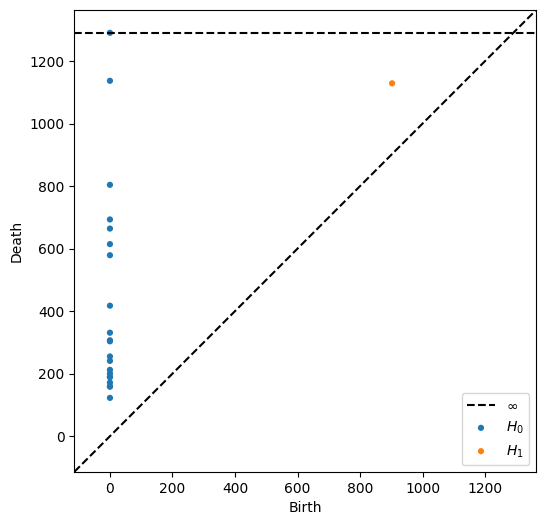

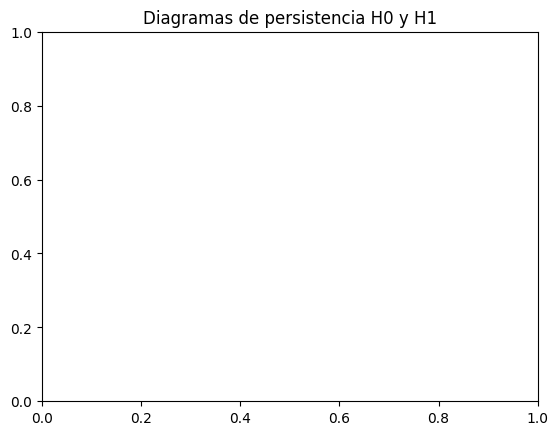

In [ ]:
# diagramas de persistencia
plt.figure(figsize=(8, 6))

plot_diagrams(
    diagramas,
    show=True
)

plt.title("Diagramas de persistencia H0 y H1")
plt.show()

In [ ]:
# transformar h0 y h1 a tablas
H0_df = pd.DataFrame(H0, columns=["birth", "death"])
H0_df["dimension"] = "H0"
H0_df["persistence"] = H0_df["death"] - H0_df["birth"]

H1_df = pd.DataFrame(H1, columns=["birth", "death"])
H1_df["dimension"] = "H1"
H1_df["persistence"] = H1_df["death"] - H1_df["birth"]

# Para H0 hay una componente que vive infinitamente
H0_df["death"] = H0_df["death"].replace(np.inf, np.nan)
H0_df["persistence"] = H0_df["persistence"].replace(np.inf, np.nan)

H0_df = H0_df.sort_values(
    by="persistence",
    ascending=False
).reset_index(drop=True)

H1_df = H1_df.sort_values(
    by="persistence",
    ascending=False
).reset_index(drop=True)

display(H0_df.head(20))
display(H1_df.head(20))

,birth,death,dimension,persistence
0,0.0,1136.781860,H0,1136.781860
1,0.0,804.035400,H0,804.035400
2,0.0,693.215210,H0,693.215210
3,0.0,664.106689,H0,664.106689
4,0.0,614.339600,H0,614.339600
5,0.0,578.886230,H0,578.886230
6,0.0,417.445526,H0,417.445526
7,0.0,330.992401,H0,330.992401
8,0.0,306.817749,H0,306.817749
9,0.0,303.424408,H0,303.424408


,birth,death,dimension,persistence
0,902.502686,1128.722168,H1,226.219482


In [ ]:
# interpretar
H0_finitas = H0_df.dropna(subset=["death"]).copy()

print("Componentes H0 finitas:", len(H0_finitas))

if len(H0_finitas) > 0:
    print("Escala mínima de conexión:", H0_finitas["death"].min())
    print("Escala máxima antes de conexión total:", H0_finitas["death"].max())
    print("Persistencia media H0:", H0_finitas["persistence"].mean())

Componentes H0 finitas: 20
Escala mínima de conexión: 122.52665710449219
Escala máxima antes de conexión total: 1136.7818603515625
Persistencia media H0: 387.48597412109376


In [ ]:
# interpretar ciclos h1
if len(H1_df) > 0:
    H1_df["es_ciclo_persistente"] = (
        H1_df["persistence"] >= H1_df["persistence"].quantile(0.75)
    )

    ciclos_persistentes = H1_df[
        H1_df["es_ciclo_persistente"]
    ].copy()

    print("Ciclos H1 detectados:", len(H1_df))
    print("Ciclos H1 persistentes:", len(ciclos_persistentes))

    display(ciclos_persistentes)
else:
    print("No se detectaron ciclos H1.")

Ciclos H1 detectados: 1
Ciclos H1 persistentes: 1


,birth,death,dimension,persistence,es_ciclo_persistente
0,902.502686,1128.722168,H1,226.219482,True


In [ ]:
# resumen topologico
resumen_homologia = pd.DataFrame({
    "dimension": ["H0", "H1"],
    "descripcion": [
        "componentes conectadas",
        "ciclos o bucles"
    ],
    "numero_caracteristicas": [
        len(H0_df),
        len(H1_df)
    ],
    "persistencia_media": [
        H0_df["persistence"].mean(),
        H1_df["persistence"].mean() if len(H1_df) > 0 else 0
    ],
    "persistencia_maxima": [
        H0_df["persistence"].max(),
        H1_df["persistence"].max() if len(H1_df) > 0 else 0
    ]
})

display(resumen_homologia)

,dimension,descripcion,numero_caracteristicas,persistencia_media,persistencia_maxima
0,H0,componentes conectadas,21,387.485974,1136.781860
1,H1,ciclos o bucles,1,226.219482,226.219482


In [ ]:
# ciclo en el grafo
G_hom = nx.DiGraph()

for _, row in aristas_topologicas.iterrows():
    G_hom.add_edge(
        row["node_origen"],
        row["node_destino"],
        weight=row["frecuencia_transicion"],
        probability=row["probabilidad_transicion"]
    )

componentes_debiles = list(nx.weakly_connected_components(G_hom))
componentes_fuertes = list(nx.strongly_connected_components(G_hom))

print("Componentes débilmente conectadas:", len(componentes_debiles))
print("Componentes fuertemente conectadas:", len(componentes_fuertes))

# Ciclos dirigidos
ciclos_dirigidos = list(nx.simple_cycles(G_hom))

print("Ciclos dirigidos encontrados:", len(ciclos_dirigidos))

ciclos_grafo = pd.DataFrame({
    "ciclo": [" -> ".join(c) for c in ciclos_dirigidos],
    "longitud_ciclo": [len(c) for c in ciclos_dirigidos]
})

display(ciclos_grafo.head(20))

Componentes débilmente conectadas: 1
Componentes fuertemente conectadas: 13
Ciclos dirigidos encontrados: 4


,ciclo,longitud_ciclo
0,HDB_13 -> HDB_20,2
1,HDB_20 -> HDB_14,2
2,HDB_20 -> HDB_11,2
3,HDB_18 -> HDB_19,2


## 2.10. Score Final


In [ ]:
aristas_score = aristas_topologicas.copy()
nodos_score = nodos_topologicos.copy()
corredores_score = corredores_metricas.copy()
if "probabilidad_transicion" not in aristas_score.columns:
    salidas_por_nodo = (
        aristas_score
        .groupby("node_origen")["frecuencia_transicion"]
        .sum()
        .reset_index(name="total_salidas_origen")
    )

    aristas_score = aristas_score.merge(
        salidas_por_nodo,
        on="node_origen",
        how="left"
    )

    aristas_score["probabilidad_transicion"] = (
        aristas_score["frecuencia_transicion"] /
        aristas_score["total_salidas_origen"]
    )
def limpiar_secuencia_nodos_score(nodos):
    secuencia = []

    for nodo in nodos:
        if pd.isna(nodo):
            continue

        if nodo == "ruido":
            continue

        if len(secuencia) == 0 or nodo != secuencia[-1]:
            secuencia.append(nodo)

    return secuencia


if "resumen_rutas" not in globals():

    resumen_lista = []

    puntos_score_base = puntos.copy()
    puntos_score_base["datetime"] = pd.to_datetime(
        puntos_score_base["datetime"],
        errors="coerce"
    )

    puntos_score_base = puntos_score_base.sort_values(
        ["storm_id", "datetime"]
    )

    for storm_id, grupo in puntos_score_base.groupby("storm_id"):

        grupo = grupo.sort_values("datetime").copy()
        secuencia_nodos = limpiar_secuencia_nodos_score(
            grupo["node_id"].tolist()
        )

        if len(secuencia_nodos) < 2:
            continue

        resumen_lista.append({
            "storm_id": storm_id,
            "name": grupo["name"].iloc[0] if "name" in grupo.columns else np.nan,
            "year": grupo["datetime"].dt.year.min(),
            "fecha_inicio": grupo["datetime"].min(),
            "fecha_fin": grupo["datetime"].max(),
            "secuencia_nodos": " -> ".join(secuencia_nodos),
            "nodos_recorridos": len(secuencia_nodos),
            "viento_maximo": grupo["max_wind_kt"].max(),
            "presion_minima": grupo["min_pressure_mb"].min(),
            "velocidad_media": grupo["velocidad_kmh_t"].mean()
        })

    resumen_rutas = pd.DataFrame(resumen_lista)
edge_lookup = aristas_score.set_index(
    ["node_origen", "node_destino"]
).to_dict("index")

if "probabilidad_aparicion" not in nodos_score.columns:
    nodos_score["probabilidad_aparicion"] = (
        nodos_score["numero_puntos_historicos"] /
        nodos_score["numero_puntos_historicos"].sum()
    )

node_lookup = nodos_score.set_index("node_id").to_dict("index")

def minmax(s):
    s = pd.Series(s)

    if s.max() == s.min():
        return s * 0

    return (s - s.min()) / (s.max() - s.min())


def obtener_nodos_trayectoria(secuencia):
    return [n.strip() for n in secuencia.split("->")]


def obtener_aristas_trayectoria(nodos):
    return list(zip(nodos[:-1], nodos[1:]))


def generar_subrutas_score(secuencia, k):
    nodos = obtener_nodos_trayectoria(secuencia)

    if len(nodos) < k:
        return []

    return [
        " -> ".join(nodos[i:i+k])
        for i in range(len(nodos) - k + 1)
    ]


def diferencia_angular(a, b):
    if pd.isna(a) or pd.isna(b):
        return np.nan

    diff = abs(a - b) % 360

    if diff > 180:
        diff = 360 - diff

    return diff


def score_probabilidad_transicion(secuencia):
    nodos = obtener_nodos_trayectoria(secuencia)
    aristas = obtener_aristas_trayectoria(nodos)

    probs = []

    for origen, destino in aristas:
        if (origen, destino) in edge_lookup:
            p = edge_lookup[(origen, destino)].get("probabilidad_transicion", 0)
            probs.append(p)

    probs = [p for p in probs if p > 0]

    if len(probs) == 0:
        return 0, 0

    log_prob_media = np.mean(np.log(probs))
    prob_acumulada = np.prod(probs)

    return log_prob_media, prob_acumulada


def score_persistencia_frecuencia(secuencia):
    subrutas = []

    for k in [2, 3, 4]:
        subrutas.extend(generar_subrutas_score(secuencia, k))

    if len(subrutas) == 0:
        return 0, 0

    valores_persistencia = []
    valores_frecuencia = []

    for subruta in subrutas:
        match = corredores_score[corredores_score["subruta"] == subruta]

        if len(match) > 0:
            if "persistencia" in match.columns:
                valores_persistencia.append(match["persistencia"].max())
            elif "score_persistencia" in match.columns:
                valores_persistencia.append(match["score_persistencia"].max())

            valores_frecuencia.append(match["frecuencia"].max())

    persistencia = np.mean(valores_persistencia) if len(valores_persistencia) > 0 else 0
    frecuencia = np.mean(valores_frecuencia) if len(valores_frecuencia) > 0 else 0

    return persistencia, frecuencia


def score_zonas_observadas(secuencia):
    nodos = obtener_nodos_trayectoria(secuencia)

    probs = []

    for nodo in nodos:
        if nodo in node_lookup:
            probs.append(node_lookup[nodo].get("probabilidad_aparicion", 0))

    if len(probs) == 0:
        return 1

    return np.mean(probs)


def score_similitud_historica(secuencia, todas_secuencias):
    nodos_actuales = set(obtener_nodos_trayectoria(secuencia))

    if len(nodos_actuales) == 0:
        return 0

    similitudes = []

    for otra in todas_secuencias:
        if otra == secuencia:
            continue

        nodos_otra = set(obtener_nodos_trayectoria(otra))

        if len(nodos_otra) == 0:
            continue

        inter = len(nodos_actuales.intersection(nodos_otra))
        union = len(nodos_actuales.union(nodos_otra))

        if union > 0:
            similitudes.append(inter / union)

    if len(similitudes) == 0:
        return 0

    return max(similitudes)


def score_coherencia_y_cambios(storm_id):
    grupo = puntos[puntos["storm_id"] == storm_id].copy()

    if "direccion_grados_t" not in grupo.columns:
        return 0, 1

    grupo = grupo.sort_values("datetime").copy()

    direcciones = grupo["direccion_grados_t"].dropna().tolist()

    if len(direcciones) < 2:
        return 0, 1

    giros = []

    for i in range(1, len(direcciones)):
        giros.append(diferencia_angular(direcciones[i-1], direcciones[i]))

    giros = pd.Series(giros).dropna()

    if len(giros) == 0:
        return 0, 1

    giro_promedio = giros.mean()

    coherencia = 1 - min(giro_promedio / 180, 1)
    penalizacion_cambios = min(giro_promedio / 180, 1)

    return coherencia, penalizacion_cambios

In [ ]:
# score
score_trayectorias = resumen_rutas.copy()

todas_secuencias = score_trayectorias["secuencia_nodos"].dropna().tolist()

resultados_score = []

for _, row in score_trayectorias.iterrows():

    secuencia = row["secuencia_nodos"]
    storm_id = row["storm_id"]

    log_prob_media, prob_acumulada = score_probabilidad_transicion(secuencia)

    persistencia_topologica, frecuencia_historica = score_persistencia_frecuencia(
        secuencia
    )

    coherencia_direccional, penalizacion_cambios_bruscos = score_coherencia_y_cambios(
        storm_id
    )

    similitud_historica = score_similitud_historica(
        secuencia,
        todas_secuencias
    )

    observacion_media = score_zonas_observadas(secuencia)

    resultados_score.append({
        "storm_id": storm_id,
        "log_probabilidad_media": log_prob_media,
        "probabilidad_acumulada": prob_acumulada,
        "persistencia_topologica": persistencia_topologica,
        "frecuencia_historica": frecuencia_historica,
        "coherencia_direccional": coherencia_direccional,
        "similitud_trayectorias_pasadas": similitud_historica,
        "observacion_media_zonas": observacion_media,
        "penalizacion_cambios_bruscos": penalizacion_cambios_bruscos
    })

componentes_score = pd.DataFrame(resultados_score)

score_trayectorias = score_trayectorias.merge(
    componentes_score,
    on="storm_id",
    how="left"
)

In [ ]:
# normalizacion
score_trayectorias["probabilidad_transicion_norm"] = minmax(
    score_trayectorias["log_probabilidad_media"]
)

score_trayectorias["persistencia_topologica_norm"] = minmax(
    score_trayectorias["persistencia_topologica"]
)

score_trayectorias["frecuencia_historica_norm"] = minmax(
    score_trayectorias["frecuencia_historica"]
)

score_trayectorias["coherencia_direccional_norm"] = minmax(
    score_trayectorias["coherencia_direccional"]
)

score_trayectorias["similitud_historica_norm"] = minmax(
    score_trayectorias["similitud_trayectorias_pasadas"]
)

score_trayectorias["penalizacion_cambios_norm"] = minmax(
    score_trayectorias["penalizacion_cambios_bruscos"]
)

score_trayectorias["penalizacion_zonas_poco_observadas"] = (
    1 - minmax(score_trayectorias["observacion_media_zonas"])
)
# score final trayectoria
score_trayectorias["score_trayectoria"] = (
    0.25 * score_trayectorias["probabilidad_transicion_norm"] +
    0.20 * score_trayectorias["persistencia_topologica_norm"] +
    0.15 * score_trayectorias["frecuencia_historica_norm"] +
    0.15 * score_trayectorias["coherencia_direccional_norm"] +
    0.15 * score_trayectorias["similitud_historica_norm"] -
    0.05 * score_trayectorias["penalizacion_cambios_norm"] -
    0.05 * score_trayectorias["penalizacion_zonas_poco_observadas"]
)

score_trayectorias["score_trayectoria"] = score_trayectorias[
    "score_trayectoria"
].clip(lower=0, upper=1)

score_trayectorias = score_trayectorias.sort_values(
    by="score_trayectoria",
    ascending=False
).reset_index(drop=True)

display(score_trayectorias.head(30))

,storm_id,name,year,month_inicio,fecha_inicio,fecha_fin,lat_inicio,lon_inicio,lat_fin,lon_fin,...,observacion_media_zonas,penalizacion_cambios_bruscos,probabilidad_transicion_norm,persistencia_topologica_norm,frecuencia_historica_norm,coherencia_direccional_norm,similitud_historica_norm,penalizacion_cambios_norm,penalizacion_zonas_poco_observadas,score_trayectoria
0,EP102010,TEN,2010,9,2010-09-03 00:00:00+00:00,2010-09-05 06:00:00+00:00,19.3,-109.0,23.3,-113.4,...,0.481553,0.013266,0.608841,1.000000,1.000000,0.987214,1.0,0.012786,0.248931,0.787207
1,EP052005,EUGENE,2005,7,2005-07-18 06:00:00+00:00,2005-07-21 18:00:00+00:00,14.8,-103.7,23.9,-113.8,...,0.481553,0.019253,0.608841,1.000000,1.000000,0.965822,1.0,0.034178,0.248931,0.782928
2,EP052013,ERICK,2013,7,2013-07-04 12:00:00+00:00,2013-07-09 18:00:00+00:00,13.2,-98.2,24.7,-113.5,...,0.481553,0.023809,0.608841,1.000000,1.000000,0.949541,1.0,0.050459,0.248931,0.779672
3,EP111970,KRISTEN,1970,8,1970-08-05 00:00:00+00:00,1970-08-08 12:00:00+00:00,16.0,-100.0,23.7,-113.2,...,0.481553,0.024324,0.608841,1.000000,1.000000,0.947701,1.0,0.052299,0.248931,0.779304
4,EP142020,ISELLE,2020,8,2020-08-25 18:00:00+00:00,2020-08-31 12:00:00+00:00,15.0,-117.5,24.8,-113.2,...,0.481553,0.036064,0.608841,1.000000,1.000000,0.905751,1.0,0.094249,0.248931,0.770914
5,EP122020,GENEVIEVE,2020,8,2020-08-16 12:00:00+00:00,2020-08-22 06:00:00+00:00,11.3,-96.5,27.0,-117.4,...,0.481553,0.046156,0.608841,1.000000,1.000000,0.869689,1.0,0.130311,0.248931,0.763702
6,EP071965,EMILY,1965,8,1965-08-30 00:00:00+00:00,1965-09-06 12:00:00+00:00,17.0,-108.4,32.5,-115.5,...,0.481553,0.046158,0.608841,1.000000,1.000000,0.869684,1.0,0.130316,0.248931,0.763701
7,EP011953,UNNAMED,1953,8,1953-08-25 00:00:00+00:00,1953-08-27 00:00:00+00:00,19.1,-109.4,24.4,-113.0,...,0.481553,0.047846,0.608841,1.000000,1.000000,0.863649,1.0,0.136351,0.248931,0.762494
8,EP051964,TILLIE,1964,9,1964-09-07 00:00:00+00:00,1964-09-09 00:00:00+00:00,20.3,-109.4,23.9,-114.2,...,0.481553,0.049621,0.608841,1.000000,1.000000,0.857309,1.0,0.142691,0.248931,0.761226
9,EP071969,GLENDA,1969,9,1969-09-08 00:00:00+00:00,1969-09-12 00:00:00+00:00,15.0,-100.7,25.9,-116.5,...,0.481553,0.049707,0.608841,1.000000,1.000000,0.857003,1.0,0.142997,0.248931,0.761164


In [ ]:
import pandas as pd
import numpy as np

# ============================================================
# DATASET FINAL PARA MODELO GRAFICO PROBABILISTICO + EXPORT CSV
# Incluye variables HURDAT + topología + ERA5 + CEM/grid
# Requiere:
# - puntos
# - nodos_topologicos
# - aristas_topologicas
# ============================================================

puntos_modelo = puntos.copy()
nodos_modelo = nodos_topologicos.copy()
aristas_modelo = aristas_topologicas.copy()

puntos_modelo["datetime"] = pd.to_datetime(
    puntos_modelo["datetime"],
    errors="coerce",
    utc=True
)

puntos_modelo = puntos_modelo.dropna(
    subset=["storm_id", "datetime", "node_id", "lat", "lon"]
).copy()

puntos_modelo = puntos_modelo[
    puntos_modelo["node_id"] != "ruido"
].copy()

puntos_modelo = puntos_modelo.sort_values(
    ["storm_id", "datetime"]
).reset_index(drop=True)

puntos_modelo["year"] = puntos_modelo["datetime"].dt.year
puntos_modelo["month"] = puntos_modelo["datetime"].dt.month

# compactar trayectorias por cambio de nodo
puntos_modelo["node_id_anterior"] = (
    puntos_modelo.groupby("storm_id")["node_id"].shift(1)
)

puntos_compacto = puntos_modelo[
    puntos_modelo["node_id"] != puntos_modelo["node_id_anterior"]
].copy()

puntos_compacto = puntos_compacto.sort_values(
    ["storm_id", "datetime"]
).reset_index(drop=True)

# ground truth: nodo actual -> nodo siguiente real
dataset_transiciones_gt = puntos_compacto.copy()
dataset_transiciones_gt["nodo_actual"] = dataset_transiciones_gt["node_id"]
dataset_transiciones_gt["nodo_siguiente_real"] = (
    dataset_transiciones_gt
    .groupby("storm_id")["node_id"]
    .shift(-1)
)

dataset_transiciones_gt["datetime_siguiente"] = (
    dataset_transiciones_gt
    .groupby("storm_id")["datetime"]
    .shift(-1)
)

dataset_transiciones_gt = dataset_transiciones_gt.dropna(
    subset=["nodo_actual", "nodo_siguiente_real"]
).copy()

dataset_transiciones_gt = dataset_transiciones_gt[
    dataset_transiciones_gt["nodo_actual"] !=
    dataset_transiciones_gt["nodo_siguiente_real"]
].copy()

# atributos del nodo actual: se renombran dinámicamente con prefijo nodo_
columnas_nodo = [c for c in nodos_modelo.columns if c != "node_id"]
nodos_origen = nodos_modelo[["node_id"] + columnas_nodo].copy()
rename_nodos = {"node_id": "nodo_actual"}
for c in columnas_nodo:
    if not c.startswith("nodo_"):
        rename_nodos[c] = f"nodo_{c}"

nodos_origen = nodos_origen.rename(columns=rename_nodos)

dataset_transiciones_gt = dataset_transiciones_gt.merge(
    nodos_origen,
    on="nodo_actual",
    how="left"
)

# probabilidades de transición en aristas
cols_previas = [
    "total_salidas_origen",
    "probabilidad_transicion",
    "probabilidad_global",
    "costo_probabilistico",
    "frecuencia_norm",
    "penalizacion_baja_frecuencia",
    "costo_dijkstra"
]

aristas_modelo = aristas_modelo.drop(
    columns=[c for c in cols_previas if c in aristas_modelo.columns],
    errors="ignore"
)

salidas = (
    aristas_modelo
    .groupby("node_origen")["frecuencia_transicion"]
    .sum()
    .reset_index(name="total_salidas_origen")
)

aristas_modelo = aristas_modelo.merge(
    salidas,
    on="node_origen",
    how="left"
)

aristas_modelo["probabilidad_transicion"] = (
    aristas_modelo["frecuencia_transicion"] /
    aristas_modelo["total_salidas_origen"]
)

total_transiciones = aristas_modelo["frecuencia_transicion"].sum()
aristas_modelo["probabilidad_global"] = (
    aristas_modelo["frecuencia_transicion"] /
    total_transiciones
)

# agregar información de arista observada al ground truth
aristas_gt = aristas_modelo.copy()
rename_aristas = {
    "node_origen": "nodo_actual",
    "node_destino": "nodo_siguiente_real"
}
for c in aristas_gt.columns:
    if c not in ["node_origen", "node_destino"]:
        rename_aristas[c] = f"gt_{c}"

aristas_gt = aristas_gt.rename(columns=rename_aristas)

columnas_arista_gt = [
    c for c in aristas_gt.columns
    if c in ["nodo_actual", "nodo_siguiente_real"] or c.startswith("gt_")
]

dataset_transiciones_gt = dataset_transiciones_gt.merge(
    aristas_gt[columnas_arista_gt],
    on=["nodo_actual", "nodo_siguiente_real"],
    how="left"
)

# variables categóricas para el modelo
def categorizar_intensidad(viento):
    if pd.isna(viento):
        return "desconocida"
    elif viento < 34:
        return "depresion_tropical"
    elif viento < 64:
        return "tormenta_tropical"
    elif viento < 83:
        return "huracan_cat_1"
    elif viento < 96:
        return "huracan_cat_2"
    elif viento < 113:
        return "huracan_cat_3"
    elif viento < 137:
        return "huracan_cat_4"
    else:
        return "huracan_cat_5"


def categorizar_direccion(grados):
    if pd.isna(grados):
        return "desconocida"
    if grados >= 337.5 or grados < 22.5:
        return "N"
    elif grados < 67.5:
        return "NE"
    elif grados < 112.5:
        return "E"
    elif grados < 157.5:
        return "SE"
    elif grados < 202.5:
        return "S"
    elif grados < 247.5:
        return "SW"
    elif grados < 292.5:
        return "W"
    else:
        return "NW"

if "max_wind_kt" in dataset_transiciones_gt.columns:
    dataset_transiciones_gt["intensidad_categoria"] = (
        dataset_transiciones_gt["max_wind_kt"].apply(categorizar_intensidad)
    )

if "direccion_grados_t" in dataset_transiciones_gt.columns:
    dataset_transiciones_gt["direccion_categoria"] = (
        dataset_transiciones_gt["direccion_grados_t"].apply(categorizar_direccion)
    )

# costos para grafo, Dijkstra o Viterbi
epsilon = 1e-12
grafo_aristas_modelo = aristas_modelo.copy()
grafo_aristas_modelo["costo_probabilistico"] = (
    -np.log(grafo_aristas_modelo["probabilidad_transicion"] + epsilon)
)
grafo_aristas_modelo["frecuencia_norm"] = (
    grafo_aristas_modelo["frecuencia_transicion"] /
    grafo_aristas_modelo["frecuencia_transicion"].max()
)
grafo_aristas_modelo["penalizacion_baja_frecuencia"] = (
    1 - grafo_aristas_modelo["frecuencia_norm"]
)
grafo_aristas_modelo["costo_dijkstra"] = (
    grafo_aristas_modelo["costo_probabilistico"] +
    0.50 * grafo_aristas_modelo["penalizacion_baja_frecuencia"]
)

# dataset limpio para entrenamiento/evaluación
base_cols = [
    "storm_id", "name", "datetime", "datetime_siguiente", "year", "month",
    "lat", "lon", "nodo_actual", "nodo_siguiente_real",
    "max_wind_kt", "min_pressure_mb", "intensidad_categoria",
    "velocidad_kmh_t", "velocidad_kt_t", "direccion_grados_t",
    "direccion_categoria", "direccion_cardinal_t",
    "cambio_lat_t", "cambio_lon_t", "cambio_intensidad_t", "cambio_presion_t",
    "distancia_recorrida_km_t"
]

cols_enriquecimiento_punto = [
    c for c in dataset_transiciones_gt.columns
    if c.startswith(("era5_", "cem_"))
]

cols_nodo = [
    c for c in dataset_transiciones_gt.columns
    if c.startswith("nodo_") and c not in ["nodo_actual", "nodo_siguiente_real"]
]

cols_gt = [
    c for c in dataset_transiciones_gt.columns
    if c.startswith("gt_")
]

columnas_modelo = base_cols + cols_enriquecimiento_punto + cols_nodo + cols_gt
columnas_modelo = [c for c in columnas_modelo if c in dataset_transiciones_gt.columns]

dataset_transiciones_gt = dataset_transiciones_gt[columnas_modelo].copy()

# tabla de nodos para el modelo
nodos_modelo_export = nodos_modelo.copy()

# diccionario de variables
diccionario_variables = pd.DataFrame([
    ["storm_id", "Identificador único del ciclón"],
    ["name", "Nombre del ciclón"],
    ["datetime", "Fecha y hora del nodo actual"],
    ["datetime_siguiente", "Fecha y hora del siguiente nodo observado"],
    ["nodo_actual", "Nodo topológico actual HDBSCAN"],
    ["nodo_siguiente_real", "Ground truth: siguiente nodo real observado"],
    ["era5_*", "Variables ambientales extraídas de ERA5 en el punto de trayectoria"],
    ["cem_*", "Variables orográficas extraídas del CEM/grid en el punto de trayectoria"],
    ["nodo_era5_*", "Agregados ERA5 por nodo topológico"],
    ["nodo_cem_*", "Agregados CEM/grid por nodo topológico"],
    ["gt_era5_*", "Agregados ERA5 por arista observada"],
    ["gt_cem_*", "Agregados CEM/grid por arista observada"],
    ["gt_probabilidad_transicion", "Probabilidad histórica de transición observada"],
    ["costo_dijkstra", "Costo de arista basado en probabilidad y frecuencia"]
], columns=["variable", "descripcion"])

# convertir fechas a texto ISO para CSV
for df_export in [dataset_transiciones_gt, grafo_aristas_modelo, nodos_modelo_export]:
    for col in df_export.columns:
        if "datetime" in col or "fecha" in col:
            df_export[col] = pd.to_datetime(
                df_export[col],
                errors="coerce",
                utc=True
            ).dt.strftime("%Y-%m-%d %H:%M:%S")

# exportar CSV
dataset_transiciones_gt.to_csv("dataset_transiciones_gt_modelo.csv", index=False, encoding="utf-8-sig")
grafo_aristas_modelo.to_csv("grafo_aristas_modelo.csv", index=False, encoding="utf-8-sig")
nodos_modelo_export.to_csv("nodos_modelo.csv", index=False, encoding="utf-8-sig")
diccionario_variables.to_csv("diccionario_variables_modelo.csv", index=False, encoding="utf-8-sig")

print("CSV generados:")
print("- dataset_transiciones_gt_modelo.csv")
print("- grafo_aristas_modelo.csv")
print("- nodos_modelo.csv")
print("- diccionario_variables_modelo.csv")

print("\nResumen:")
print("Transiciones ground truth:", len(dataset_transiciones_gt))
print("Nodos origen únicos:", dataset_transiciones_gt["nodo_actual"].nunique())
print("Nodos destino únicos:", dataset_transiciones_gt["nodo_siguiente_real"].nunique())
print("Aristas para grafo:", len(grafo_aristas_modelo))
print("Nodos del modelo:", len(nodos_modelo_export))

print("\nColumnas ERA5/CEM en dataset final:")
print([c for c in dataset_transiciones_gt.columns if c.startswith(("era5_", "cem_", "nodo_era5_", "nodo_cem_", "gt_era5_", "gt_cem_"))])

display(dataset_transiciones_gt.head(20))
display(grafo_aristas_modelo.head(20))
display(nodos_modelo_export.head(20))

try:
    from google.colab import files
    files.download("dataset_transiciones_gt_modelo.csv")
    files.download("grafo_aristas_modelo.csv")
    files.download("nodos_modelo.csv")
    files.download("diccionario_variables_modelo.csv")
except:
    print("Descarga automática disponible solo en Google Colab.")


CSV generados:
- dataset_transiciones_gt_modelo.csv
- grafo_aristas_modelo.csv
- nodos_modelo.csv
- diccionario_variables_modelo.csv

Resumen:
Transiciones ground truth: 461
Nodos origen únicos: 21
Nodos destino únicos: 20
Aristas para grafo: 24
Nodos del modelo: 21

Columnas ERA5/CEM en dataset final:
['era5_sst_c', 'era5_msl_hpa', 'era5_t2m_c', 'era5_d2m_c', 'era5_rh700_pct', 'era5_rh500_pct', 'era5_q700_kgkg', 'era5_vo850_s1', 'era5_u850_ms', 'era5_v850_ms', 'era5_u200_ms', 'era5_v200_ms', 'era5_shear_200_850_ms', 'cem_elevacion_m', 'cem_pendiente_grados', 'cem_rugosidad_3x3_m', 'cem_distancia_tierra_km', 'cem_elevacion_cercana_m', 'cem_pendiente_cercana_grados', 'cem_rugosidad_cercana_m', 'cem_elevacion_media_25km', 'cem_elevacion_max_25km', 'cem_pendiente_media_25km', 'cem_pendiente_max_25km', 'cem_rugosidad_media_25km', 'cem_rugosidad_max_25km', 'cem_celdas_validas_25km', 'cem_elevacion_media_50km', 'cem_elevacion_max_50km', 'cem_pendiente_media_50km', 'cem_pendiente_max_50km', '

,storm_id,name,datetime,datetime_siguiente,year,month,lat,lon,nodo_actual,nodo_siguiente_real,...,gt_cem_rugosidad_max_500km_max_arista,gt_cem_rugosidad_max_500km_cobertura_arista,gt_direccion_media_grados,gt_meses_donde_ocurre,gt_cem_clase_interaccion_100km_dominante_arista,gt_cem_clase_interaccion_250km_dominante_arista,gt_cem_clase_interaccion_500km_dominante_arista,gt_total_salidas_origen,gt_probabilidad_transicion,gt_probabilidad_global
0,CP032013,THREE,2013-08-09 12:00:00,2013-08-10 18:00:00,2013,8,11.2,-116.2,HDB_6,HDB_20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EP011953,UNNAMED,1953-08-25 00:00:00,1953-08-26 18:00:00,1953,8,19.1,-109.4,HDB_20,HDB_19,...,1236.0,1.0,323.519944,"9 (10), 8 (4), 7 (1), 10 (1)",sin_interaccion,baja,baja,95.0,0.168421,0.107383
2,EP011964,NATALIE,1964-07-06 00:00:00,1964-07-07 00:00:00,1964,7,16.8,-104.9,HDB_20,HDB_3,...,1533.0,1.0,36.839707,10 (3),muy_baja,media,media,95.0,0.031579,0.020134
3,EP011970,ADELE,1970-05-31 06:00:00,1970-05-31 18:00:00,1970,5,10.9,-100.4,HDB_20,HDB_11,...,NaN,0.0,267.434900,"11 (2), 9 (1)",sin_interaccion,sin_interaccion,NaN,95.0,0.031579,0.020134
4,EP011970,ADELE,1970-05-31 18:00:00,1970-06-03 12:00:00,1970,5,10.9,-101.9,HDB_11,HDB_6,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,EP011970,ADELE,1970-06-03 12:00:00,1970-06-04 06:00:00,1970,6,11.3,-117.2,HDB_6,HDB_20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,EP011973,AVA,1973-06-03 12:00:00,1973-06-08 06:00:00,1973,6,12.3,-95.4,HDB_20,HDB_13,...,NaN,0.0,280.974601,"7 (4), 10 (3), 6 (2), 8 (1)",sin_interaccion,sin_interaccion,NaN,95.0,0.115789,0.073826
7,EP011973,AVA,1973-06-08 06:00:00,1973-06-08 12:00:00,1973,6,13.1,-116.6,HDB_13,HDB_20,...,NaN,0.0,299.585149,"10 (4), 6 (3), 8 (2), 9 (1)",sin_interaccion,sin_interaccion,NaN,10.0,1.000000,0.067114
8,EP011979,ANDRES,1979-06-01 00:00:00,1979-06-01 18:00:00,1979,6,11.0,-96.2,HDB_12,HDB_20,...,1208.0,1.0,295.598520,7 (2),sin_interaccion,sin_interaccion,muy_baja,2.0,1.000000,0.013423
9,EP011980,AGATHA,1980-06-11 12:00:00,1980-06-12 00:00:00,1980,6,11.4,-116.8,HDB_6,HDB_20,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


,node_origen,node_destino,edge_id,frecuencia_transicion,huracanes_unicos,anios_unicos,velocidad_media,velocidad_maxima,cambio_promedio_intensidad,cambio_maximo_intensidad,...,cem_clase_interaccion_100km_dominante_arista,cem_clase_interaccion_250km_dominante_arista,cem_clase_interaccion_500km_dominante_arista,total_salidas_origen,probabilidad_transicion,probabilidad_global,costo_probabilistico,frecuencia_norm,penalizacion_baja_frecuencia,costo_dijkstra
0,HDB_20,HDB_16,HDB_20 -> HDB_16,22,22,21,17.809873,39.086268,-4.772727,0.0,...,sin_interaccion,sin_interaccion,NaN,95,0.231579,0.147651,1.462834e+00,1.000000,0.000000,1.462834
1,HDB_20,HDB_14,HDB_20 -> HDB_14,18,18,16,18.601237,28.621691,-4.166667,0.0,...,sin_interaccion,sin_interaccion,NaN,95,0.189474,0.120805,1.663505e+00,0.818182,0.181818,1.754414
2,HDB_20,HDB_19,HDB_20 -> HDB_19,16,16,15,17.011746,31.609502,-2.812500,5.0,...,sin_interaccion,baja,baja,95,0.168421,0.107383,1.781288e+00,0.727273,0.272727,1.917652
3,HDB_16,HDB_15,HDB_16 -> HDB_15,13,13,12,14.908548,24.161544,-1.923077,5.0,...,sin_interaccion,sin_interaccion,NaN,13,1.000000,0.087248,-1.000089e-12,0.590909,0.409091,0.204545
4,HDB_20,HDB_13,HDB_20 -> HDB_13,11,11,11,17.463360,24.670224,0.909091,5.0,...,sin_interaccion,sin_interaccion,NaN,95,0.115789,0.073826,2.155982e+00,0.500000,0.500000,2.405982
5,HDB_13,HDB_20,HDB_13 -> HDB_20,10,10,10,22.880658,32.660821,-0.500000,5.0,...,sin_interaccion,sin_interaccion,NaN,10,1.000000,0.067114,-1.000089e-12,0.454545,0.545455,0.272727
6,HDB_20,HDB_10,HDB_20 -> HDB_10,8,8,8,20.863715,28.612761,-5.000000,0.0,...,sin_interaccion,sin_interaccion,NaN,95,0.084211,0.053691,2.474435e+00,0.363636,0.636364,2.792617
7,HDB_11,HDB_20,HDB_11 -> HDB_20,6,6,6,15.119471,17.957359,4.166667,10.0,...,sin_interaccion,sin_interaccion,NaN,6,1.000000,0.040268,-1.000089e-12,0.272727,0.727273,0.363636
8,HDB_20,HDB_17,HDB_20 -> HDB_17,6,6,6,21.161937,36.337023,-2.500000,0.0,...,sin_interaccion,sin_interaccion,muy_baja,95,0.063158,0.040268,2.762117e+00,0.272727,0.727273,3.125754
9,HDB_7,HDB_5,HDB_7 -> HDB_5,5,5,5,16.328745,20.742287,-4.000000,0.0,...,sin_interaccion,sin_interaccion,muy_baja,9,0.555556,0.033557,5.877867e-01,0.227273,0.772727,0.974150


,node_id,cluster_hdbscan,lat_centro,lon_centro,lat_min,lat_max,lon_min,lon_max,numero_puntos_historicos,numero_huracanes_unicos,...,cem_rugosidad_max_500km_max,cem_rugosidad_max_500km_cobertura,meses_frecuentes,direccion_dominante,cem_clase_interaccion_100km_dominante,cem_clase_interaccion_250km_dominante,cem_clase_interaccion_500km_dominante,probabilidad_aparicion,duracion_historica_dias,duracion_historica_anios
0,HDB_20,20,16.571373,-111.313795,10.7,23.5,-125.0,-94.8,15440,1043,...,3038.0,0.581347,"9 (3584), 8 (3278), 7 (3230)",W,sin_interaccion,sin_interaccion,baja,0.959006,27898.50,76.381930
1,HDB_19,19,24.034848,-113.153030,23.3,24.7,-113.9,-112.6,66,39,...,1236.0,1.000000,"9 (46), 8 (13), 7 (4)",NW,sin_interaccion,baja,baja,0.004099,26664.00,73.002053
2,HDB_16,16,21.914545,-122.690909,21.4,22.7,-123.3,-121.6,55,36,...,NaN,0.000000,"8 (21), 9 (15), 7 (14)",W,sin_interaccion,sin_interaccion,NaN,0.003416,24083.25,65.936345
3,HDB_2,2,27.020370,-112.922222,25.8,28.5,-114.3,-111.9,54,30,...,1533.0,1.000000,"9 (32), 8 (13), 10 (7)",N,media,media,media,0.003354,24890.50,68.146475
4,HDB_18,18,24.361538,-114.630769,23.7,25.3,-115.0,-114.3,39,28,...,1236.0,1.000000,"9 (23), 8 (6), 10 (6)",NW,sin_interaccion,muy_baja,baja,0.002422,25965.50,71.089665
5,HDB_10,10,20.227586,-124.800000,19.7,20.7,-125.0,-124.3,29,28,...,NaN,0.000000,"7 (11), 8 (10), 9 (5)",W,sin_interaccion,sin_interaccion,NaN,0.001801,25626.50,70.161533
6,HDB_14,14,21.490323,-118.938710,20.9,21.9,-119.4,-118.4,31,26,...,NaN,0.000000,"8 (11), 7 (8), 9 (8)",NW,sin_interaccion,sin_interaccion,NaN,0.001925,24800.00,67.898700
7,HDB_3,3,22.585714,-106.997143,21.6,23.9,-107.5,-106.6,35,24,...,1533.0,1.000000,"10 (16), 9 (12), 7 (3)",N,baja,media,media,0.002174,23367.50,63.976728
8,HDB_6,6,11.277500,-117.570000,11.0,11.7,-118.6,-116.2,40,22,...,NaN,0.000000,"8 (15), 7 (12), 6 (8)",W,sin_interaccion,sin_interaccion,NaN,0.002484,17925.25,49.076660
9,HDB_4,4,23.795238,-122.288095,23.1,24.7,-123.4,-121.1,42,21,...,NaN,0.000000,"8 (16), 7 (14), 10 (6)",W,sin_interaccion,sin_interaccion,NaN,0.002609,24069.50,65.898700


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>